# 32 · score: 밀도 대신 밀도의 기울기를 배우기

**이번 질문:** 정규화 상수 $Z$를 모르는 밀도 $p(x)=e^{-E(x)}/Z$에서 데이터만으로 배울 수 있는 양은 무엇이고, 정답을 모르는데 어떻게 회귀 문제가 될까요?

23번에서 두 봉우리 혼합의 밀도 $p(x)$와 책임확률을 손으로 계산했습니다. 그런데 실제 데이터의 밀도에는 그런 닫힌식이 없고, 신경망으로 $p(x)$를 직접 쓰려 해도 "전체 적분이 1"이 되게 하는 상수 $Z$가 발목을 잡습니다.
이번에는 밀도 대신 **밀도의 기울기** $\nabla_x\log p(x)$(score)를 배웁니다. 미분하면 $Z$가 사라지고, 잡음을 더하면 정답 없이도 회귀 타깃이 생기며, 배운 기울기를 따라 점을 옮기면 샘플이 나옵니다.
혼합의 정확한 score → 정답 없이 쓰는 목적(Hyvärinen) → 잡음 조건부 타깃(DSM) → MLP score 모델 학습 → 오르막과 Langevin 한 걸음 순서로 갑니다.

- 준비물: [12](../02_연결/12_gaussian_information.ipynb)의 로그 밀도, [23](23_latent_mixture_em.ipynb)의 책임확률·`mix_score`·`mix_denoiser`, [01](../00_기초/01_gradients_and_learning.ipynb)·[03](../00_기초/03_perceptron_to_mlp.ipynb)의 MSE 회귀와 MLP backward, [13](../02_연결/13_autodiff.ipynb)의 VJP.
- 도착점: 혼합의 해석적 score, Hyvärinen 항등식, DSM의 잡음 조건부 타깃을 숫자로 확인하고, MLP score 모델을 학습해 정답 벡터장과 비교한 뒤 score로 점을 옮깁니다.
- 다음 연결: [33 NCSN](33_ncsn.ipynb)은 잡음 수준 $\sigma$ 여러 개를 하나의 모델로 잇고 annealed Langevin으로 샘플을 만듭니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. score는 $s(x)=\nabla_x\log p(x)$입니다. $\log p=-E(x)-\log Z$를 $x$로 미분하면 상수 $\log Z$가 사라지므로 정규화 없이 정의됩니다. 혼합에서는 책임확률의 가중합 `np.sum(r * (MIX_MU - x[:, None]) / MIX_SIGMA ** 2, axis=1)`입니다.
2. 잡음을 더한 $\tilde x=x+\sigma\epsilon$에서는 조건부 score $-\epsilon/\sigma$가 정답 역할을 합니다. DSM 손실 `np.mean(np.sum((S + eps / sigma) ** 2, axis=1))`의 최소해는 잡음 낀 분포 $q_\sigma$의 score이고, 혼합이면 분산 $\sigma_k^2+\sigma^2$의 닫힌식입니다.
3. score를 따라 걷는 한 걸음 `x + alpha / 2 * s(x)`는 봉우리로 오르고, 잡음 `+ np.sqrt(alpha) * z`를 섞은 Langevin 한 걸음은 분포를 따라 퍼집니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/score_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents)          # 현재 폴더부터 위로 올라가며
                    if (p / "src/utils/plotting.py").is_file())            # src/utils/plotting.py가 있는 첫 폴더를 고릅니다
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(1절부터: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 이 노트북의 그림 함수(src/utils/score_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.utils.score_plots import (
    plot_curves, plot_score_overview, plot_hyvarinen, plot_noisy_scores, plot_dsm_regression,
    plot_learned_score_1d, plot_learned_field_2d, plot_dynamics, plot_sigma_comparison,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· score 준비 완료")

NumPy 2.4.6 · score 준비 완료


### 📎 이 노트북의 예시: 1차원 두 봉우리 혼합, 2차원 혼합

- **1차원 두 봉우리 혼합.** 23번의 공통 상황입니다. 비율 $\pi=(0.3, 0.7)$, 평균 $\mu=(-2, 2)$, 표준편차 $\sigma=(0.5, 1)$인 두 Gaussian을 섞은 분포입니다. 밀도·책임확률·score·잡음 뒤 최적 복원이 모두 닫힌식이라, 이 노트북에서 신경망이 배운 결과의 **정답지**로 씁니다.
- **2차원 혼합.** 같은 규약의 2차원 판입니다. score가 벡터장(화살표 그림)으로 보입니다.
- 이 노트북은 MNIST를 쓰지 않습니다. 이미지 좌표(PCA-32)의 score 학습은 [33](33_ncsn.ipynb)에서 같은 코드로 합니다.

> **용어**
>
> - **혼합(mixture) 분포**: 성분 $k$를 비율 $\pi_k$로 고른 뒤 그 Gaussian에서 점을 뽑는 분포. 밀도는 $p(x)=\sum_k\pi_k\mathcal N(x;\mu_k,\sigma_k^2)$ (23번 1절). 코드에서는 성분별 로그 항을 logsumexp로 더합니다.
> - **책임확률(responsibility)** $r_k(x)=p(z=k\mid x)$: 점 $x$가 성분 $k$에서 왔을 확률. 로그 항의 softmax (23번 2절). 코드에서는 `np.exp(terms - max)`를 행 합으로 나눕니다.

아래 셀은 실행만 하고 넘어가도 됩니다. 3절에서 잡음 $\sigma$를 더한 혼합도 같은 함수로 다루기 위해, 성분 분산을 $\sigma_k^2+\sigma^2$로 바꾸는 `sigma` 인자를 두었습니다. `sigma=0`이면 23번의 원래 함수와 같습니다.

> **코드**
>
> - `x[:, None]`: `(N,)`을 `(N, 1)`로 세워 `(2,)`짜리 성분 배열과 브로드캐스팅. 결과는 `(N, 2)` = 점마다 성분 두 개.
> - `terms.max(axis=1, keepdims=True)`: 행마다 최댓값을 `(N, 1)`로 남겨 빼기 쉽게 합니다. 지수가 넘치지 않게 하는 02번 8절의 안정화입니다.
> - `np.linalg.solve(C, d.T).T`: 관측마다 $C^{-1}d$를 한 번에 (12번 2절). `np.linalg.slogdet(C)[1]`은 $\log\det C$.
> - `rng.choice(2, size=n, p=MIX_PI)`: 0 또는 1을 확률 `MIX_PI`로 n번 뽑습니다. 잠재 성분 $z$의 ancestral sampling (23번 5절).
> - `np.linalg.cholesky(MIX2_COV)`: `(2, 2, 2)`를 성분마다 분해해 $\Sigma_k=L_kL_k^\top$의 `L` `(2, 2, 2)`를 냅니다.
> - `np.einsum("nij,nj->ni", L[z], epsilon)`: 점마다 행렬 `L[z][n]` `(2, 2)`을 벡터 `epsilon[n]` `(2,)`에 곱합니다. 12번 1절의 $\mu+L\epsilon$을 n개 점에 한 번에 (23번 5절).

In [2]:
MIX_PI = np.array([0.3, 0.7])                                        # (2,): 성분 비율 π_k
MIX_MU = np.array([-2.0, 2.0])                                       # (2,): 성분 평균 μ_k
MIX_SIGMA = np.array([0.5, 1.0])                                     # (2,): 성분 표준편차 σ_k
MIX2_PI = np.array([0.4, 0.6])                                       # (2,): 2차원 혼합의 비율
MIX2_MU = np.array([[-2.0, 0.0], [2.0, 1.0]])                        # (2, 2): 성분 평균 (행 = 성분)
MIX2_COV = np.array([[[0.6, 0.2], [0.2, 0.5]], [[0.4, -0.1], [-0.1, 0.8]]])   # (2, 2, 2): 성분 공분산 Σ_k
print("1차원 π, μ, σ:", MIX_PI, MIX_MU, MIX_SIGMA, "· 2차원 평균", MIX2_MU.tolist())

1차원 π, μ, σ: [0.3 0.7] [-2.  2.] [0.5 1. ] · 2차원 평균 [[-2.0, 0.0], [2.0, 1.0]]


In [3]:
def mix_log_terms(x, sigma=0.0):
    """성분별 log π_k + log N(x; μ_k, σ_k² + σ²). sigma 는 3절에서 더하는 잡음의 표준편차(0이면 원래 혼합). x: (N,) → (N, 2)."""
    variances = MIX_SIGMA ** 2 + sigma ** 2                          # (2,): 성분 분산
    squared = (x[:, None] - MIX_MU) ** 2 / variances                 # (N, 2): 표준화한 제곱 거리
    return np.log(MIX_PI) - 0.5 * (np.log(2 * np.pi * variances) + squared)


def mix_logpdf(x, sigma=0.0):
    """23번 1절: log p(x) = logsumexp_k [log π_k + log N(x; μ_k, σ_k²)]. sigma 를 주면 잡음 낀 q_σ (3절). x: (N,) → (N,)."""
    terms = mix_log_terms(x, sigma)
    biggest = terms.max(axis=1, keepdims=True)                       # (N, 1): 행마다 최댓값 (안정화)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix_responsibility(x, sigma=0.0):
    """23번 2절: r_k(x) = softmax_k 로그 항. sigma 를 주면 q_σ 의 책임확률 (3절). x: (N,) → (N, 2), 행 합 1."""
    terms = mix_log_terms(x, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))       # (N, 2)
    return shifted / shifted.sum(axis=1, keepdims=True)


def mix_sample(n, rng):
    """23번 5절 ancestral sampling: z ~ π 를 뽑고 x ~ N(μ_z, σ_z²). n: 개수 → (n,)."""
    z = rng.choice(2, size=n, p=MIX_PI)                              # (n,): 성분 번호
    return MIX_MU[z] + MIX_SIGMA[z] * rng.normal(size=n)

In [4]:
def mix2_log_terms(X, sigma=0.0):
    """2차원 성분별 log π_k + log N(x; μ_k, Σ_k + σ²I). X: (N, 2) → (N, 2)."""
    terms = np.zeros((len(X), 2))
    for k in range(2):
        covariance = MIX2_COV[k] + sigma ** 2 * np.eye(2)            # (2, 2): 잡음을 더한 공분산
        difference = X - MIX2_MU[k]                                  # (N, 2): x − μ_k
        squared = np.sum(difference * np.linalg.solve(covariance, difference.T).T, axis=1)   # (N,): (x−μ)ᵀ Σ⁻¹ (x−μ)
        terms[:, k] = np.log(MIX2_PI[k]) - 0.5 * (2 * np.log(2 * np.pi) + np.linalg.slogdet(covariance)[1] + squared)
    return terms


def mix2_logpdf(X, sigma=0.0):
    """2차원 혼합의 log p(x) (23번 1절). X: (N, 2) → (N,)."""
    terms = mix2_log_terms(X, sigma)
    biggest = terms.max(axis=1, keepdims=True)
    return (biggest + np.log(np.exp(terms - biggest).sum(axis=1, keepdims=True)))[:, 0]


def mix2_responsibility(X, sigma=0.0):
    """2차원 혼합의 책임확률 (23번 2절). X: (N, 2) → (N, 2)."""
    terms = mix2_log_terms(X, sigma)
    shifted = np.exp(terms - terms.max(axis=1, keepdims=True))
    return shifted / shifted.sum(axis=1, keepdims=True)


def mix2_sample(n, rng):
    """2차원 ancestral sampling: z ~ π, x = μ_z + L_z ε (12번 1절의 Cholesky). n: 개수 → (n, 2)."""
    z = rng.choice(2, size=n, p=MIX2_PI)                             # (n,)
    epsilon = rng.normal(size=(n, 2))                                # (n, 2): 독립 표준정규
    L = np.linalg.cholesky(MIX2_COV)                                 # (2, 2, 2): 성분마다 Σ_k = L_k L_kᵀ
    return MIX2_MU[z] + np.einsum("nij,nj->ni", L[z], epsilon)

In [5]:
check_x = np.linspace(-12, 12, 24001)                                # (24001,): 적분 격자
np.testing.assert_allclose(np.trapezoid(np.exp(mix_logpdf(check_x)), check_x), 1.0, atol=1e-8)   # 검산: 밀도의 적분 = 1
np.testing.assert_allclose(mix_responsibility(check_x).sum(axis=1), 1.0)                        # 검산: 책임확률 행 합 = 1
np.testing.assert_allclose(mix_responsibility(np.array([0.])), [[0.0021, 0.9979]], atol=1e-4)   # 검산: 23번 2절의 손계산 r(0)
sample_check = mix_sample(20000, np.random.default_rng(23))
np.testing.assert_allclose(sample_check.mean(), np.sum(MIX_PI * MIX_MU), atol=0.05)             # 검산: 샘플 평균 ≈ Σ π_k μ_k = 0.8
print("밀도 적분 1 · r(0) =", mix_responsibility(np.array([0.]))[0], "· 20,000개 샘플 평균", sample_check.mean().round(3), "(닫힌식 0.8)")

밀도 적분 1 · r(0) = [0.0021 0.9979] · 20,000개 샘플 평균 0.782 (닫힌식 0.8)


## 🔑 1. score: 밀도의 기울기에서는 정규화 상수가 사라집니다

**이 절에서 가져갈 것:** $\log p(x)=-E(x)-\log Z$를 $x$로 미분하면 상수 $\log Z$가 사라지므로, score $s(x)=\nabla_x\log p(x)$는 정규화 없이 정의됩니다. 혼합의 score는 책임확률로 가중한 성분별 기울기 $\sum_k r_k(x)(\mu_k-x)/\sigma_k^2$입니다 (23번 3절).

두 봉우리 사이 어딘가에 서 있다고 합시다. "어느 쪽으로 한 걸음 가면 밀도가 높아지나"를 화살표로 적은 것이 score입니다. 밀도 자체의 값(예: 0.03)은 몰라도 화살표의 방향과 길이는 정할 수 있습니다.

> **용어**
>
> - **score** $s(x)=\nabla_x\log p(x)$: 로그 밀도를 **입력** $x$로 미분한 벡터. 01번의 기울기는 파라미터로 미분했지만, 여기서는 점 $x$가 움직일 때 밀도가 어떻게 바뀌는지를 봅니다. 코드에서는 `mix_score(x)`.
> - **에너지(energy)** $E(x)$와 **정규화 상수** $Z$: 밀도를 $p(x)=e^{-E(x)}/Z$로 쓸 때 $Z=\int e^{-E(x)}dx$는 적분이 1이 되게 하는 상수. 고차원에서는 계산할 수 없는 경우가 대부분입니다.
> - **벡터장(vector field)**: 점마다 화살표 하나가 붙은 것. 2차원 score는 격자 위 화살표 그림으로 봅니다.

$$p(x)=\frac{e^{-E(x)}}{Z},\qquad \log p(x)=-E(x)-\log Z,\qquad s(x)=\nabla_x\log p(x)=-\nabla_xE(x).$$

밀도를 몰라도 에너지의 기울기만 알면 score가 나옵니다. $Z$가 얼마든 미분하면 0이기 때문입니다. 혼합에서는 로그 밀도를 성분별 항의 logsumexp로 썼으므로, 미분하면 각 항의 미분이 책임확률로 가중됩니다.

$$s(x)=\frac{\partial}{\partial x}\log\sum_k\pi_k\mathcal N(x;\mu_k,\sigma_k^2)
=\sum_k\underbrace{\frac{\pi_k\mathcal N_k(x)}{\sum_j\pi_j\mathcal N_j(x)}}_{r_k(x)}\cdot\frac{\mu_k-x}{\sigma_k^2}.$$

$x$가 $(N,)$이면 책임확률 $r$은 $(N,2)$, 성분별 기울기 $(\mu_k-x)/\sigma_k^2$도 $(N,2)$이고, 성분 축으로 더해 $(N,)$이 됩니다. 2차원에서는 성분별 기울기가 $\Sigma_k^{-1}(\mu_k-x)$이고 결과는 $(N,2)$ 벡터장입니다.

손계산 $x=0$: 23번의 $r(0)\approx(0.0021, 0.9979)$이므로 $s(0)=0.0021\cdot\frac{-2-0}{0.25}+0.9979\cdot\frac{2-0}{1}=-0.0170+1.9958\approx1.979$. 오른쪽 봉우리 쪽(양수)입니다.

아래는 1차원 격자의 score와 2차원 격자의 벡터장입니다. 구현 함수 없이 위 식을 NumPy로 그대로 씁니다.

> **코드**
>
> - `pdf[1:-1] > pdf[:-2]`: 한 칸 왼쪽보다 큰 자리. `& (pdf[1:-1] > pdf[2:])`로 오른쪽보다도 큰 자리를 고르면 국소 최대(봉우리)입니다.
> - `np.meshgrid(xs, ys)`: 가로 격자 `xs`와 세로 격자 `ys`에서 모든 (x, y) 쌍의 좌표 두 배열 `(len(ys), len(xs))`. `np.column_stack([xx.ravel(), yy.ravel()])`로 펴면 `(점 수, 2)`.
> - `r[:, k:k + 1]`: k번째 열을 `(N, 1)`로 남겨 `(N, 2)` 벡터에 브로드캐스팅.

In [6]:
# 쓰는 것: MIX_MU, MIX_SIGMA, MIX2_MU, MIX2_COV (📎 데이터 셀) · mix_logpdf, mix_responsibility, mix2_logpdf, mix2_responsibility (📎 혼합 셀)
score_x = np.linspace(-6, 6, 1201)                                   # (1201,): 1차원 격자 (간격 0.01)
score_pdf = np.exp(mix_logpdf(score_x))                              # (1201,): p(x)
score_r = mix_responsibility(score_x)                                # (1201, 2): 책임확률
score_grid = np.sum(score_r * (MIX_MU - score_x[:, None]) / MIX_SIGMA ** 2, axis=1)   # (1201,): s(x) = Σ_k r_k (μ_k − x)/σ_k²
score_modes = score_x[1:-1][(score_pdf[1:-1] > score_pdf[:-2]) & (score_pdf[1:-1] > score_pdf[2:])]   # 봉우리 = 밀도의 국소 최대
arrow_x = np.array([-4., -3., -1., 0., 1., 3.5, 5.])                # (7,): 화살표를 그릴 자리
arrow_r = mix_responsibility(arrow_x)                                # (7, 2)
arrow_score = np.sum(arrow_r * (MIX_MU - arrow_x[:, None]) / MIX_SIGMA ** 2, axis=1)   # (7,)
field_xx, field_yy = np.meshgrid(np.linspace(-5, 5, 17), np.linspace(-3, 4, 12))   # (12, 17) 둘: 화살표 격자
field_X = np.column_stack([field_xx.ravel(), field_yy.ravel()])     # (204, 2): 격자 점
field_r = mix2_responsibility(field_X)                               # (204, 2)
field_S = np.zeros_like(field_X)                                     # (204, 2): s(x) = Σ_k r_k Σ_k⁻¹(μ_k − x)
for k in range(2):
    field_S += field_r[:, k:k + 1] * np.linalg.solve(MIX2_COV[k], (MIX2_MU[k] - field_X).T).T
dense_xx, dense_yy = np.meshgrid(np.linspace(-5, 5, 121), np.linspace(-3, 4, 85))   # (85, 121) 둘: 등고선용 촘촘한 격자
dense_pdf = np.exp(mix2_logpdf(np.column_stack([dense_xx.ravel(), dense_yy.ravel()]))).reshape(dense_xx.shape)
print("봉우리:", score_modes.round(3), "· x = 0 의 책임확률", arrow_r[3].round(4), "· s(0) =", arrow_score[3].round(4))

봉우리: [-2.  2.] · x = 0 의 책임확률 [0.0021 0.9979] · s(0) = 1.9788


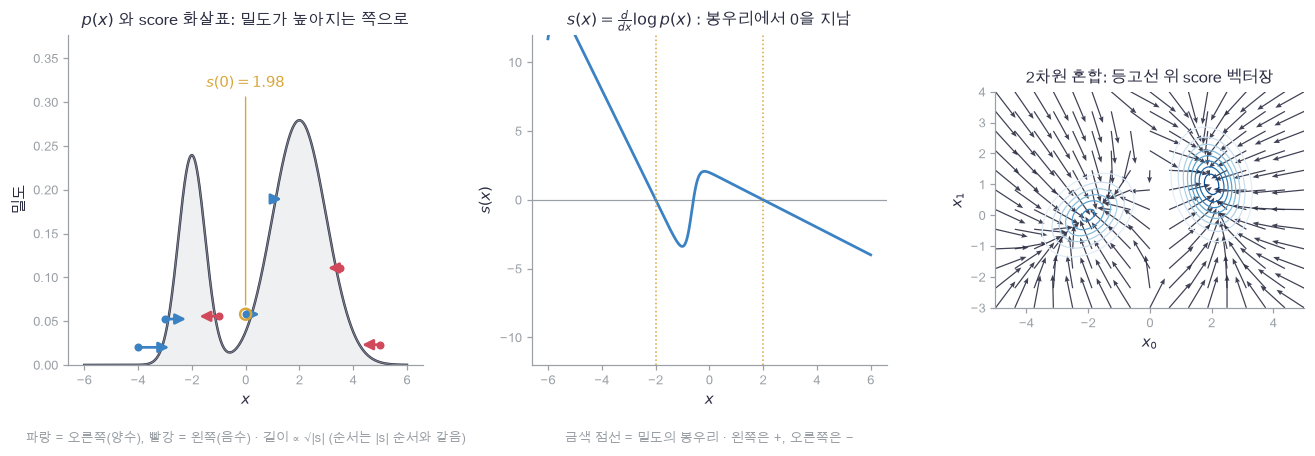

In [7]:
plot_score_overview(score_x, score_pdf, score_grid, arrow_x, arrow_score, score_modes, field_xx, field_yy, field_S, dense_xx, dense_yy, dense_pdf)

🔍 **확인** · 왼쪽 화살표는 모두 가까운 봉우리를 향합니다. 왼쪽 봉우리 근처의 화살표가 더 긴 것은 $\sigma_1=0.5$로 좁은 봉우리라 $1/\sigma_1^2=4$배로 급하기 때문입니다. 금색 점 $x=0$의 $s(0)=1.98$이 손계산과 같습니다. 화살표 길이는 $\sqrt{|s|}$에 비례하도록 줄여 그렸습니다. 길이 순서는 $|s|$ 순서와 같지만 비율은 그대로가 아닙니다(맨 왼쪽 $s=8$, 맨 오른쪽 $s=-3$).
가운데 score 곡선은 봉우리($x\approx-2, 2$)에서 0을 지나며 그 왼쪽은 양수, 오른쪽은 음수입니다. 오른쪽 2차원 벡터장도 등고선을 가로질러 봉우리 쪽을 향합니다.

아래 구현은 위 식을 그대로 함수로 만든 것입니다. 검산에서는 로그 밀도를 중심차분한 값과 비교하고, 밀도를 일부러 5배 틀린 $Z$로 두어도 같은 score가 나오는지 봅니다.

In [8]:
def mix_score(x):
    """23번 3절: 1차원 혼합의 score s(x) = Σ_k r_k(x) (μ_k − x)/σ_k². x: (N,) → (N,)."""
    # 쓰는 것: MIX_MU, MIX_SIGMA (📎 데이터 셀) · mix_responsibility (📎 혼합 셀)
    r = mix_responsibility(x)                                        # (N, 2)
    return np.sum(r * (MIX_MU - x[:, None]) / MIX_SIGMA ** 2, axis=1)


def mix2_score(X):
    """2차원 혼합의 score s(x) = Σ_k r_k(x) Σ_k⁻¹(μ_k − x). X: (N, 2) → (N, 2)."""
    # 쓰는 것: MIX2_MU, MIX2_COV (📎 데이터 셀) · mix2_responsibility (📎 혼합 셀)
    r = mix2_responsibility(X)                                       # (N, 2)
    S = np.zeros_like(X)
    for k in range(2):
        S += r[:, k:k + 1] * np.linalg.solve(MIX2_COV[k], (MIX2_MU[k] - X).T).T   # 성분 k 의 기여
    return S

In [9]:
# 쓰는 것: score_x, score_grid, score_modes, field_X, field_S (1절 계산 셀) · mix_logpdf, mix2_logpdf (📎 혼합 셀)
rng = np.random.default_rng(32)                                      # 이 노트북의 검산용 난수 생성기. 3·4절도 이어 씁니다
probe_x = rng.uniform(-5, 5, size=6)                                 # (6,): 1차원 검사 점
probe_X = rng.uniform(-4, 4, size=(5, 2))                            # (5, 2): 2차원 검사 점
wrong_scale = 5.0                                                    # 밀도를 5·p(x) 로 잘못 정규화한 경우


def logpdf_sum():
    """검사기용: 검사 점들의 log p 의 합. 점마다 독립이라 x_i 로 미분하면 s(x_i)."""
    return float(np.sum(mix_logpdf(probe_x)))


def wrong_logpdf_sum():
    """검사기용: 정규화가 틀린 log(5·p) 의 합. 상수 log 5 가 더해졌을 뿐입니다."""
    return float(np.sum(mix_logpdf(probe_x) + np.log(wrong_scale)))


def logpdf2_sum():
    """검사기용: 2차원 검사 점들의 log p 의 합."""
    return float(np.sum(mix2_logpdf(probe_X)))


score_errors = [rel_error(mix_score(probe_x), numerical_gradient(logpdf_sum, probe_x)),
                rel_error(mix_score(probe_x), numerical_gradient(wrong_logpdf_sum, probe_x)),
                rel_error(mix2_score(probe_X), numerical_gradient(logpdf2_sum, probe_X))]
assert max(score_errors) < 1e-7, "세 경우 모두 score 가 중심차분과 1e−7 안에서 같아야 합니다"
np.testing.assert_allclose(mix_score(np.array([0.])), [1.9788], atol=1e-4)   # 검산: 손계산 s(0) = −0.0170 + 1.9958
np.testing.assert_allclose(mix_score(score_x), score_grid)                   # 검산: 위 그림의 score 곡선과 같음
np.testing.assert_allclose(mix2_score(field_X), field_S)                     # 검산: 위 그림의 벡터장과 같음
np.testing.assert_allclose(mix_score(score_modes), 0, atol=0.05)             # 검산: 봉우리에서 score ≈ 0 (격자 간격 0.01 × 곡률 4)
print("score 중심차분 최대 상대오차:", max(score_errors), "· Z 를 5배 틀려도 같은 값")

score 중심차분 최대 상대오차: 3.442502758490083e-10 · Z 를 5배 틀려도 같은 값


🔍 **확인** · 1차원·2차원 모두 score가 중심차분과 $10^{-7}$ 안에서 같고, 밀도를 $5p(x)$로 잘못 정규화해도 상대오차는 그대로입니다. $\log 5$는 상수라 미분에서 사라집니다. 봉우리에서는 score가 0입니다.

### ✏️ 연습 1 · 2차원 혼합의 score 한 줄

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

2차원 점 `X` `(N, 2)`와 책임확률 `R` `(N, 2)`에서 $s(x)=\sum_kr_k(x)\Sigma_k^{-1}(\mu_k-x)$를 만듭니다. 성분 반복문은 써 두었으니 성분 $k$의 기여를 `S`에 더하는 한 줄을 채우세요. 1절 본문은 1차원이었고, 여기서는 $1/\sigma_k^2$이 $\Sigma_k^{-1}$(연립방정식 풀기)로 바뀝니다.

In [10]:

def exercise_mix2_score(X, R):
    """연습 1: 2차원 혼합의 score. X: (N, 2), R: (N, 2) 책임확률 → S: (N, 2)."""
    assert X.shape == R.shape, "점과 책임확률은 같은 (N, 2) 모양이어야 합니다"
    S = np.zeros_like(X)                                             # (N, 2): 성분 기여를 여기에 더합니다
    for k in range(2):
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: S 에 R[:, k] 로 가중한 Σ_k⁻¹(μ_k − X) 를 더하기 (모양 (N, 2))
        ### 힌트: 1절 계산 셀의 한 줄. np.linalg.solve(MIX2_COV[k], (MIX2_MU[k] - X).T).T 에 R[:, k:k + 1] 을 곱합니다.
        raise NotImplementedError
    return S

In [11]:

def check_mix2_score(candidate):
    """책임확률이 (1, 0)인 손계산 하나, 1절 그림의 벡터장, 로그 밀도의 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: MIX2_MU (📎 데이터 셀) · field_X, field_r, field_S (1절 계산 셀) · mix2_logpdf, mix2_responsibility (📎 혼합 셀)
    hand_X = MIX2_MU[0] + np.array([[1., 0.]])                       # (1, 2): 성분 0 의 평균에서 오른쪽으로 1
    hand_S = candidate(hand_X, np.array([[1., 0.]]))                 # 책임확률을 (1, 0)으로 두면 성분 0 의 기울기만
    np.testing.assert_allclose(hand_S, [[-0.5 / 0.26, 0.2 / 0.26]], atol=1e-12)   # 검산: Σ_0⁻¹(−1, 0) = (−0.5, 0.2)/det, det = 0.6·0.5 − 0.2² = 0.26
    np.testing.assert_allclose(candidate(field_X, field_r), field_S)              # 검산: 1절 그림의 벡터장
    X_c = np.random.default_rng(311).uniform(-3, 3, size=(4, 2))

    def logpdf_c():
        """검사기용: 검사 점들의 log p 합."""
        return float(np.sum(mix2_logpdf(X_c)))

    assert rel_error(candidate(X_c, mix2_responsibility(X_c)), numerical_gradient(logpdf_c, X_c)) < 1e-7, "중심차분과 1e−7 안에서 같아야 합니다"
    print("2차원 score: 손계산·벡터장·중심차분과 일치합니다.")

run_check(check_mix2_score, exercise_mix2_score, hint="S += R[:, k:k + 1] * np.linalg.solve(MIX2_COV[k], (MIX2_MU[k] - X).T).T")

☐ exercise_mix2_score: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: S += R[:, k:k + 1] * np.linalg.solve(MIX2_COV[k], (MIX2_MU[k] - X).T).T


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
S += R[:, k:k + 1] * np.linalg.solve(MIX2_COV[k], (MIX2_MU[k] - X).T).T
```

</details>

## 🔑 2. score matching: 정답 score 없이 쓰는 목적

**이 절에서 가져갈 것:** 정답과의 제곱오차 $\frac12\mathbb E_p[(s_\theta(x)-s(x))^2]$는 부분적분으로 $\mathbb E_p[\frac12 s_\theta(x)^2+s_\theta'(x)]+\text{상수}$가 됩니다. 뒤의 식에는 정답 $s$가 없으므로 데이터의 평균만으로 계산할 수 있고, 상수는 $\theta$와 무관해 최소해가 같습니다 (Hyvärinen 2005).

데이터 $x_1,\ldots,x_N$은 있지만 밀도 $p$도 정답 score $s$도 모릅니다. 01번처럼 "예측 − 정답"의 제곱을 평균내는 회귀 손실은 정답이 없어서 못 씁니다. 그런데 제곱을 풀어 쓰면 정답이 들어간 항이 데이터 평균으로 바뀝니다.

> **용어**
>
> - **Fisher divergence** $\frac12\mathbb E_p\|s_\theta(x)-\nabla\log p(x)\|^2$: 모델 score와 정답 score의 평균 제곱 거리. 12번의 KL처럼 두 분포의 거리이지만 밀도값 대신 기울기를 비교합니다.
> - **부분적분(integration by parts)**: $\int u\,v'\,dx=[uv]-\int u'\,v\,dx$. 미분을 한쪽에서 다른 쪽으로 옮기는 규칙입니다.
> - **발산(divergence)** $\nabla\cdot s_\theta=\sum_i\partial s_{\theta,i}/\partial x_i$: 벡터장의 각 성분을 같은 좌표로 미분해 더한 것. 1차원에서는 그냥 도함수 $s_\theta'(x)$입니다.

1차원에서 제곱을 풀면 세 항입니다.

$$\frac12\mathbb E_p[(s_\theta-s)^2]=\frac12\mathbb E_p[s_\theta^2]-\mathbb E_p[s_\theta s]+\frac12\mathbb E_p[s^2].$$

가운데 항에 $s=p'/p$를 넣으면 $\mathbb E_p[s_\theta s]=\int s_\theta\,p'\,dx=[s_\theta p]_{-\infty}^{\infty}-\int s_\theta'\,p\,dx=-\mathbb E_p[s_\theta']$입니다. 양 끝에서 $p\to0$이라 경계항이 사라집니다. 그래서

$$\frac12\mathbb E_p[(s_\theta-s)^2]=\underbrace{\mathbb E_p\left[\tfrac12 s_\theta(x)^2+s_\theta'(x)\right]}_{\text{정답 없이 계산}}+\underbrace{\tfrac12\mathbb E_p[s^2]}_{\theta\text{와 무관}}.$$

데이터 $x$가 $(N,)$이면 $s_\theta(x)$와 $s_\theta'(x)$도 $(N,)$이고, 목적은 `np.mean(0.5 * s ** 2 + ds)` 숫자 하나입니다. $D$차원에서는 $s_\theta'$ 자리에 발산 $\nabla\cdot s_\theta$가 옵니다. 같은 부분적분에서 $\mathbb E_p[s]=0$, $\mathbb E_p[x\,s(x)]=-1$도 나옵니다($s_\theta=1$, $s_\theta=x$를 대입).

손계산 $p=\mathcal N(0,1)$, $s(x)=-x$, $s_\theta(x)=ax$: 정답을 아는 식은 $\frac12(a+1)^2\mathbb E[x^2]=\frac12(a+1)^2$, 정답 없는 식은 $\frac12a^2+a$, 차이는 $\frac12=\frac12\mathbb E[s^2]$. $a=-\frac12$이면 $0.125$와 $-0.375$입니다.

아래는 혼합 분포에서 시험용 $s_\theta$ 세 개로 두 식을 격자 적분한 값입니다.

> **코드**
>
> - `np.trapezoid(y, x)`: 사다리꼴 규칙의 수치 적분 $\int y\,dx$. 밀도를 곱해 적분하면 $\mathbb E_p[\cdot]$입니다.
> - `np.gradient(y, x)`: 격자 위 함수의 도함수를 중심차분으로. `y`, `x` 모두 `(N,)`이고 결과도 `(N,)`.

In [12]:
# 쓰는 것: mix_logpdf (📎 혼합 셀) · mix_score (1절)
sm_x = np.linspace(-8, 8, 4001)                                      # (4001,): 적분 격자 (꼬리까지)
sm_p = np.exp(mix_logpdf(sm_x))                                      # (4001,): p(x)
sm_true = mix_score(sm_x)                                            # (4001,): 정답 score
sm_tests = {"$s_a(x) = -x$": -sm_x, "$s_b(x) = -(x - 1)/2$": -(sm_x - 1) / 2, "$s_c(x) = 2\\sin x$": 2 * np.sin(sm_x)}   # 시험용 s_θ 세 개
sm_explicit, sm_implicit = [], []
for s_test in sm_tests.values():
    ds_test = np.gradient(s_test, sm_x)                              # (4001,): s_θ'(x) 중심차분
    sm_explicit.append(0.5 * np.trapezoid(sm_p * (s_test - sm_true) ** 2, sm_x))   # ½ E_p[(s_θ − s)²]: 정답을 아는 식
    sm_implicit.append(np.trapezoid(sm_p * (0.5 * s_test ** 2 + ds_test), sm_x))   # E_p[½ s_θ² + s_θ']: 정답 없는 식
sm_constant = 0.5 * np.trapezoid(sm_p * sm_true ** 2, sm_x)         # ½ E_p[s²]: θ 와 무관한 상수
print("정답을 아는 식:", np.round(sm_explicit, 4), "\n정답 없는 식:  ", np.round(sm_implicit, 4))
print("차이:", np.round(np.subtract(sm_explicit, sm_implicit), 4), "· 상수 ½E[s²] =", sm_constant.round(4))

정답을 아는 식: [2.254  0.8883 1.4736] 
정답 없는 식:   [1.3875 0.0219 0.6071]
차이: [0.8665 0.8665 0.8665] · 상수 ½E[s²] = 0.8665


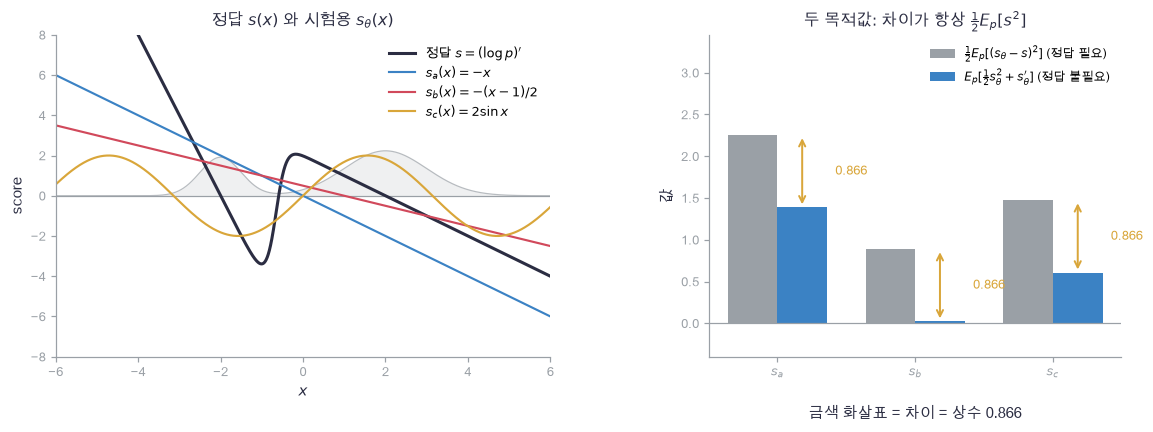

In [13]:
plot_hyvarinen(sm_x, sm_p, sm_true, sm_tests, sm_explicit, sm_implicit, sm_constant)

🔍 **확인** · 세 시험 함수 중 어느 것도 정답과 같지 않지만, 두 목적값의 차이(금색 화살표)는 셋 다 $0.866$으로 같습니다. 정답 없는 식을 가장 작게 만드는 $s_\theta$가 정답을 아는 식도 가장 작게 만듭니다. $s_b$가 셋 중 정답에 가장 가깝고, 그것을 두 식이 같은 순서로 말해 줍니다.

아래 구현은 두 목적을 가중치(밀도 × 격자 간격, 또는 샘플이면 $1/N$)로 받는 함수이고, 검산은 손계산·두 항등식·선형 모델의 닫힌 최소해를 봅니다.

> **코드** · `np.linalg.solve(A, b)`: $A\theta=b$의 해 $\theta$. 2×2 정규방정식을 풉니다 (11번 1절의 최소제곱).

In [14]:
def score_matching_objective(s_values, ds_values, weights):
    """Hyvärinen 목적 E_p[½ s_θ² + s_θ'] 를 가중 합으로. s_values, ds_values, weights: (N,) (가중치 합 1) → 숫자."""
    return float(np.sum(weights * (0.5 * s_values ** 2 + ds_values)))


def fisher_divergence(s_values, true_values, weights):
    """정답을 아는 식 ½ E_p[(s_θ − s)²] 를 가중 합으로. s_values, true_values, weights: (N,) → 숫자."""
    return float(0.5 * np.sum(weights * (s_values - true_values) ** 2))

In [15]:
# 쓰는 것: rng (1절 검산 셀) · mix_sample (📎 혼합 셀) · sm_x, sm_p, sm_true, sm_explicit, sm_implicit, sm_constant (2절 계산 셀)
normal_x = np.linspace(-9, 9, 3601)                                  # (3601,): 손계산용 표준정규 격자
normal_w = np.exp(-0.5 * normal_x ** 2) / np.sqrt(2 * np.pi) * (normal_x[1] - normal_x[0])   # (3601,): p(x) Δx
np.testing.assert_allclose(score_matching_objective(-0.5 * normal_x, np.full_like(normal_x, -0.5), normal_w), -0.375, atol=1e-6)   # 검산: 손계산 ½a² + a, a = −½
np.testing.assert_allclose(fisher_divergence(-0.5 * normal_x, -normal_x, normal_w), 0.125, atol=1e-6)                             # 검산: 손계산 ½(a + 1)²
sm_w = sm_p * (sm_x[1] - sm_x[0])                                    # (4001,): 혼합의 p(x) Δx
np.testing.assert_allclose(np.sum(sm_w * sm_true), 0, atol=1e-3)     # 검산: 항등식 E_p[s] = 0
np.testing.assert_allclose(np.sum(sm_w * sm_x * sm_true), -1, atol=1e-3)   # 검산: 항등식 E_p[x s] = −1
for s_test, explicit, implicit in zip(sm_tests.values(), sm_explicit, sm_implicit):
    np.testing.assert_allclose(fisher_divergence(s_test, sm_true, sm_w), explicit, rtol=1e-6)                    # 검산: 위 그림의 값
    np.testing.assert_allclose(score_matching_objective(s_test, np.gradient(s_test, sm_x), sm_w), implicit, rtol=1e-6)   # 검산: 위 그림의 값 (정답 없는 식)
    np.testing.assert_allclose(explicit - implicit, sm_constant, atol=1e-5)                                    # 검산: 차이 = 상수
moments = np.array([[np.sum(sm_w * sm_x ** 2), np.sum(sm_w * sm_x)], [np.sum(sm_w * sm_x), 1.]])   # (2, 2): 선형 모델 s_θ = a x + b 의 정규방정식
ab_explicit = np.linalg.solve(moments, [np.sum(sm_w * sm_x * sm_true), np.sum(sm_w * sm_true)])   # 정답에 회귀한 (a, b)
ab_implicit = np.linalg.solve(moments, [-1., 0.])                    # 정답 없는 식의 최소해: a E[x²] + b E[x] + 1 = 0, a E[x] + b = 0
np.testing.assert_allclose(ab_implicit, ab_explicit, atol=1e-6)      # 검산: 두 목적의 최소해가 같음
sample_x = mix_sample(20000, rng)                                    # (20000,): 데이터로 잰 목적 (격자 대신 샘플 평균)
sample_objective = score_matching_objective(-sample_x, np.full(20000, -1.), np.full(20000, 1 / 20000))
assert abs(sample_objective - sm_implicit[0]) < 0.05, "샘플 평균으로 잰 목적이 격자 적분과 0.05 안에서 같아야 합니다"
print("선형 모델 최소해 (a, b): 정답 회귀", ab_explicit.round(4), "= 정답 없는 식", ab_implicit.round(4), "· s_a 의 목적을 샘플 20,000개로:", round(sample_objective, 4))

선형 모델 최소해 (a, b): 정답 회귀 [-0.2418  0.1935] = 정답 없는 식 [-0.2418  0.1935] · s_a 의 목적을 샘플 20,000개로: 1.3852


🔍 **확인** · 표준정규 손계산 $0.125$와 $-0.375$가 맞고, 항등식 $\mathbb E_p[s]=0$, $\mathbb E_p[xs]=-1$이 격자 적분에서 성립합니다. 선형 모델 $s_\theta=ax+b$의 최소해는 정답에 회귀하든 정답 없는 식을 풀든 같은 $(a,b)$입니다. 데이터 20,000개의 평균으로 잰 목적도 격자 적분과 가깝습니다.

📎 이 목적에는 도함수 $s_\theta'$(고차원에서는 발산)가 필요합니다. 신경망 $s_\theta$에서는 좌표마다 한 번씩 역전파해야 하므로 차원 $D$에 비례하는 비용이 듭니다. 3절은 그 도함수 없이 같은 최소해를 얻는 방법입니다.

### ✏️ 연습 2 · 정답 없는 목적의 두 항

격자 `x` `(N,)`와 그 위의 모델 값 `s_values` `(N,)`에서 정답 없는 식의 안쪽 $\frac12 s_\theta(x)^2+s_\theta'(x)$를 점마다 만듭니다. 도함수는 중심차분 `np.gradient`로 구하는 줄과 두 항을 더하는 줄, 두 줄을 채우세요. 가중 평균은 검사 함수가 합니다.

In [16]:

def exercise_hyvarinen_terms(x, s_values):
    """연습 2: 점마다 ½ s_θ² + s_θ' (도함수는 중심차분). x, s_values: (N,) → terms: (N,)."""
    assert x.shape == s_values.shape, "격자와 모델 값은 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: ds = s_values 를 x 로 중심차분한 도함수 (N,), terms = 0.5 * s_values² + ds (N,)
    ### 힌트: 2절 계산 셀의 np.gradient(s_test, sm_x) 와 0.5 * s_test ** 2 + ds_test
    raise NotImplementedError
    return terms

In [17]:

def check_hyvarinen_terms(candidate):
    """s = −x 의 손계산(½x² − 1)과 2절의 목적값으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: sm_x, sm_tests, sm_implicit (2절 계산 셀) · sm_w (2절 검산 셀)
    hand_x = np.linspace(-3, 3, 601)
    hand_terms = candidate(hand_x, -hand_x)
    np.testing.assert_allclose(hand_terms, 0.5 * hand_x ** 2 - 1, atol=1e-10)                        # 검산: 손계산 ½x² + (−1)
    np.testing.assert_allclose(candidate(np.array([0., 1., 2.]), -np.array([0., 1., 2.])), [-1., -0.5, 1.])   # 검산: x = 0, 1, 2 에서 −1, −½, 1
    for s_test, implicit in zip(sm_tests.values(), sm_implicit):
        np.testing.assert_allclose(np.sum(sm_w * candidate(sm_x, s_test)), implicit, rtol=1e-8)        # 검산: 2절 그림의 정답 없는 목적값
    print("정답 없는 목적의 두 항: 손계산·2절 목적값과 일치합니다.")

run_check(check_hyvarinen_terms, exercise_hyvarinen_terms, hint="ds = np.gradient(s_values, x) · terms = 0.5 * s_values ** 2 + ds")

☐ exercise_hyvarinen_terms: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: ds = np.gradient(s_values, x) · terms = 0.5 * s_values ** 2 + ds


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
ds = np.gradient(s_values, x)
terms = 0.5 * s_values ** 2 + ds
```

</details>

## 🔑 3. DSM: 잡음을 더하면 조건부 타깃이 생깁니다

**이 절에서 가져갈 것:** 데이터 $x$에 잡음을 더해 $\tilde x=x+\sigma\epsilon$을 만들면 "어디서 왔는지"를 아니까 조건부 score $\nabla_{\tilde x}\log q(\tilde x\mid x)=-(\tilde x-x)/\sigma^2=-\epsilon/\sigma$를 정답으로 쓸 수 있습니다. 이 회귀(DSM)의 최소해는 원래 $p$가 아니라 잡음 낀 분포 $q_\sigma$의 score이고, 혼합이면 분산 $\sigma_k^2+\sigma^2$의 닫힌식입니다 (Vincent 2011).

2절의 목적은 도함수가 필요했습니다. 대신 이렇게 해 봅시다. 데이터 점 $x=1$에 잡음을 더해 $\tilde x=1.5$가 되었다면, $\tilde x$에서 $x$로 돌아가는 방향은 압니다. 그 방향을 $\tilde x$에서의 정답으로 삼습니다.

> **용어**
>
> - **잡음 낀 분포** $q_\sigma(\tilde x)=\int p(x)\mathcal N(\tilde x;x,\sigma^2)dx$: 데이터에 표준편차 $\sigma$의 Gaussian 잡음을 더한 뒤의 분포. 혼합이면 성분 분산이 $\sigma_k^2+\sigma^2$로 커진 혼합입니다 (23번 5절).
> - **조건부 score** $\nabla_{\tilde x}\log q(\tilde x\mid x)$: 원래 점 $x$를 알 때 잡음 낀 점 $\tilde x$의 로그 밀도 기울기. Gaussian이라 $-(\tilde x-x)/\sigma^2$로 바로 나옵니다.
> - **DSM(denoising score matching)**: 모델 $s_\theta(\tilde x)$를 조건부 score $-\epsilon/\sigma$에 회귀하는 학습. 코드에서는 `np.mean((s + eps / sigma) ** 2)`.
> - **Tweedie 공식**: 잡음 뒤 최적 복원과 score의 관계 $\mathbb E[x\mid\tilde x]=\tilde x+\sigma^2\nabla_{\tilde x}\log q_\sigma(\tilde x)$. 23번의 `mix_denoiser`와 이 절의 score를 잇습니다.

$$q(\tilde x\mid x)=\mathcal N(\tilde x;x,\sigma^2),\qquad \nabla_{\tilde x}\log q(\tilde x\mid x)=-\frac{\tilde x-x}{\sigma^2}=-\frac{\epsilon}{\sigma}\quad(\tilde x=x+\sigma\epsilon).$$

$$J_{DSM}(\theta)=\mathbb E_{x\sim p,\ \epsilon\sim\mathcal N(0,1)}\left[\left(s_\theta(x+\sigma\epsilon)+\frac{\epsilon}{\sigma}\right)^2\right].$$

$\tilde x$가 정해지면 타깃 $-\epsilon/\sigma$는 여전히 흔들리는 값입니다(같은 $\tilde x$가 여러 $x$에서 올 수 있으니). 제곱오차의 최소해는 조건부 평균입니다($c$를 상수로 두면 $\mathbb E[(c-T)^2]$는 $c$로 미분해 $2(c-\mathbb E[T])=0$, 즉 $c=\mathbb E[T]$에서 최소이고 여기서는 $\tilde x$를 고정한 조건부 기댓값입니다). 그래서 최소해는 $s^*(\tilde x)=\mathbb E[-\epsilon/\sigma\mid\tilde x]$이고, 이것이 $\nabla\log q_\sigma(\tilde x)$입니다. $\int p(x)\nabla_{\tilde x}\mathcal N(\tilde x;x,\sigma^2)dx=\nabla_{\tilde x}q_\sigma(\tilde x)$를 $q_\sigma$로 나누면 나옵니다.

혼합에서는 $q_\sigma=\sum_k\pi_k\mathcal N(\mu_k,\sigma_k^2+\sigma^2)$이므로 1절의 식에서 분산만 바꾸면 됩니다.

$$\nabla\log q_\sigma(\tilde x)=\sum_kr_k^{\sigma}(\tilde x)\frac{\mu_k-\tilde x}{\sigma_k^2+\sigma^2},\qquad
\frac{\mathbb E[x\mid\tilde x]-\tilde x}{\sigma^2}=\nabla\log q_\sigma(\tilde x)\ \text{(Tweedie)}.$$

$\tilde x$가 $(N,)$이면 $r^\sigma$는 $(N,2)$, 결과 $(N,)$. 2차원은 공분산 $\Sigma_k+\sigma^2I$이고 결과 $(N,2)$.

손계산: $x=1$, $\sigma=0.5$, $\epsilon=1$이면 $\tilde x=1.5$, 타깃은 $-(1.5-1)/0.25=-2=-\epsilon/\sigma$. $\sigma=1$, $\tilde x=0$에서는 분산이 $(1.25, 2)$라 $r^\sigma(0)\approx(0.229, 0.771)$, score는 $0.229\cdot\frac{-2}{1.25}+0.771\cdot\frac{2}{2}=-0.367+0.771\approx0.404$. 1절의 $s(0)=1.979$보다 훨씬 완만합니다.

아래는 점 $x=1$에 잡음을 여섯 번 더한 타깃과, $\sigma$ 세 값에서 $q_\sigma$의 밀도·score입니다.

In [18]:
# 쓰는 것: MIX_MU, MIX_SIGMA (📎 데이터 셀) · mix_logpdf, mix_responsibility (📎 혼합 셀) · rng (1절 검산 셀) · score_x, score_pdf, score_grid (1절 계산 셀)
dsm_clean = 1.0                                                      # 깨끗한 점 x
dsm_sigma_demo = 0.5
dsm_eps = rng.normal(size=6)                                         # (6,): 잡음 ε 여섯 개
dsm_noisy = dsm_clean + dsm_sigma_demo * dsm_eps                     # (6,): x̃ = x + σε
dsm_targets = -(dsm_noisy - dsm_clean) / dsm_sigma_demo ** 2         # (6,): 조건부 score −(x̃ − x)/σ² = −ε/σ
noisy_sigmas = [0.3, 1.0]
noisy_pdfs, noisy_scores = [score_pdf], [score_grid]                 # σ = 0 (원래 p) 부터
for sigma in noisy_sigmas:
    variances = MIX_SIGMA ** 2 + sigma ** 2                          # (2,): 성분 분산 σ_k² + σ²
    r_sigma = mix_responsibility(score_x, sigma)                     # (1201, 2): q_σ 의 책임확률
    noisy_pdfs.append(np.exp(mix_logpdf(score_x, sigma)))            # (1201,): q_σ(x)
    noisy_scores.append(np.sum(r_sigma * (MIX_MU - score_x[:, None]) / variances, axis=1))   # (1201,): q_σ 의 score
center = np.argmin(np.abs(score_x))                                  # x = 0 의 격자 번호
np.testing.assert_allclose(dsm_targets, -dsm_eps / dsm_sigma_demo)   # 검산: −(x̃ − x)/σ² = −ε/σ
print("x̃ =", dsm_noisy.round(3), "\n타깃 −ε/σ =", dsm_targets.round(3))
print("σ = 1 에서 q_σ 의 score(0) =", noisy_scores[2][center].round(4), "· 원래 s(0) =", score_grid[center].round(4))

x̃ = [1.537 1.282 1.413 0.758 0.951 1.067] 
타깃 −ε/σ = [-2.147 -1.13  -1.651  0.969  0.195 -0.268]
σ = 1 에서 q_σ 의 score(0) = 0.4038 · 원래 s(0) = 1.9788


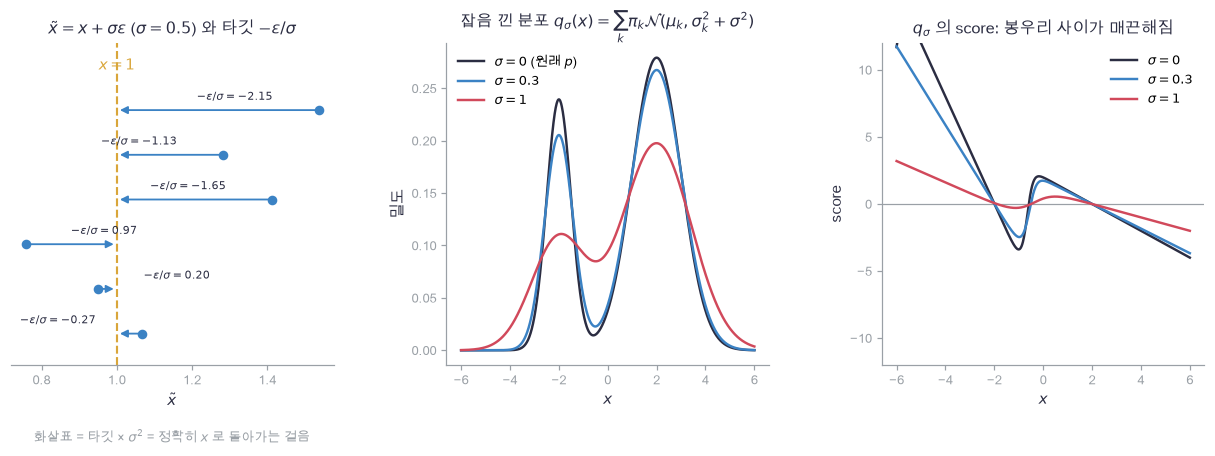

In [19]:
plot_noisy_scores(dsm_clean, dsm_noisy, dsm_targets, dsm_sigma_demo, score_x, [0.0] + noisy_sigmas, noisy_pdfs, noisy_scores)

🔍 **확인** · 왼쪽 파란 점은 같은 $x=1$에서 나온 여섯 개의 $\tilde x$이고, 타깃 $-\epsilon/\sigma$에 $\sigma^2$을 곱한 화살표는 정확히 $x$로 돌아갑니다. 타깃은 "잡음을 되돌리는 방향"입니다. 가운데는 $\sigma$가 커질수록 두 봉우리 사이의 골이 메워지는 $q_\sigma$이고, 오른쪽 score는 그만큼 완만해집니다. $\sigma=1$의 $s(0)=0.40$이 손계산과 같습니다.

아래 구현은 타깃, $q_\sigma$의 score(1·2차원), 그리고 23번 5절의 `mix_denoiser`입니다. 검산은 손계산, 중심차분, Tweedie 항등, 그리고 "DSM의 최소해가 정말 $q_\sigma$의 score인지"를 격자 최소제곱으로 봅니다.

In [20]:
def dsm_target(x_clean, x_noisy, sigma):
    """조건부 score = DSM 타깃: −(x̃ − x)/σ² (= −ε/σ). x_clean, x_noisy: 같은 모양 → 같은 모양."""
    return -(x_noisy - x_clean) / sigma ** 2


def mix_score_noisy(x, sigma):
    """잡음 낀 혼합 q_σ 의 score: Σ_k r_k^σ(x) (μ_k − x)/(σ_k² + σ²). x: (N,), sigma: 숫자 → (N,)."""
    # 쓰는 것: MIX_MU, MIX_SIGMA (📎 데이터 셀) · mix_responsibility (📎 혼합 셀)
    r = mix_responsibility(x, sigma)                                 # (N, 2): 분산 σ_k² + σ² 의 책임확률
    return np.sum(r * (MIX_MU - x[:, None]) / (MIX_SIGMA ** 2 + sigma ** 2), axis=1)


def mix2_score_noisy(X, sigma):
    """2차원 q_σ 의 score: Σ_k r_k^σ (Σ_k + σ²I)⁻¹(μ_k − x). X: (N, 2) → (N, 2)."""
    # 쓰는 것: MIX2_MU, MIX2_COV (📎 데이터 셀) · mix2_responsibility (📎 혼합 셀)
    r = mix2_responsibility(X, sigma)
    S = np.zeros_like(X)
    for k in range(2):
        S += r[:, k:k + 1] * np.linalg.solve(MIX2_COV[k] + sigma ** 2 * np.eye(2), (MIX2_MU[k] - X).T).T
    return S

In [21]:
def mix_denoiser(x_noisy, sigma):
    """23번 5절: 잡음 뒤 최적 복원 E[x | x̃] = Σ_k r_k^σ(x̃) [μ_k + σ_k²/(σ_k² + σ²) (x̃ − μ_k)]. x_noisy: (N,) → (N,)."""
    # 쓰는 것: MIX_MU, MIX_SIGMA (📎 데이터 셀) · mix_responsibility (📎 혼합 셀)
    r = mix_responsibility(x_noisy, sigma)                           # (N, 2): 분산 σ_k² + σ² 의 책임확률
    shrink = MIX_SIGMA ** 2 / (MIX_SIGMA ** 2 + sigma ** 2)          # (2,): 성분별로 x̃ 를 μ_k 쪽으로 당기는 비율
    return np.sum(r * (MIX_MU + shrink * (x_noisy[:, None] - MIX_MU)), axis=1)

In [22]:
# 쓰는 것: probe_x, probe_X (1절 검산 셀) · mix_score (1절) · dsm_noisy, dsm_targets, noisy_scores, noisy_sigmas (3절 계산 셀) · score_x (1절 계산 셀) · mix_logpdf, mix2_logpdf (📎 혼합 셀)
np.testing.assert_allclose(dsm_target(1.0, 1.5, 0.5), -2.0)          # 검산: 손계산 −(1.5 − 1)/0.25 = −2
np.testing.assert_allclose(dsm_target(1.0, dsm_noisy, 0.5), dsm_targets)   # 검산: 위 그림의 타깃
np.testing.assert_allclose(mix_score_noisy(np.array([0.]), 1.0), [0.4038], atol=1e-4)   # 검산: 손계산 −0.367 + 0.771
np.testing.assert_allclose(mix_score_noisy(probe_x, 0.0), mix_score(probe_x))           # 검산: σ = 0 이면 원래 score
for sigma, s_sigma in zip(noisy_sigmas, noisy_scores[1:]):
    np.testing.assert_allclose(mix_score_noisy(score_x, sigma), s_sigma)                # 검산: 위 그림의 σ 별 score 곡선


def noisy_logpdf_sum():
    """검사기용: 검사 점들의 log q_σ (σ = 0.7) 의 합."""
    return float(np.sum(mix_logpdf(probe_x, 0.7)))


def noisy_logpdf2_sum():
    """검사기용: 2차원 검사 점들의 log q_σ (σ = 0.7) 의 합."""
    return float(np.sum(mix2_logpdf(probe_X, 0.7)))


noisy_errors = [rel_error(mix_score_noisy(probe_x, 0.7), numerical_gradient(noisy_logpdf_sum, probe_x)),
                rel_error(mix2_score_noisy(probe_X, 0.7), numerical_gradient(noisy_logpdf2_sum, probe_X))]
assert max(noisy_errors) < 1e-7, "q_σ 의 score 가 log q_σ 의 중심차분과 1e−7 안에서 같아야 합니다"
tweedie_x = np.linspace(-5, 5, 21)
for sigma in [0.3, 1.0, 2.0]:
    np.testing.assert_allclose((mix_denoiser(tweedie_x, sigma) - tweedie_x) / sigma ** 2, mix_score_noisy(tweedie_x, sigma), atol=1e-10)   # 검산: Tweedie (E[x|x̃] − x̃)/σ² = ∇ log q_σ
np.testing.assert_allclose(mix_denoiser(np.array([0.]), 1.0), [0.4038], atol=1e-4)   # 검산: 손계산 E[x | x̃ = 0] = 0 + 1² × 0.4038
print("q_σ score 중심차분 최대 상대오차:", max(noisy_errors), "· Tweedie 항등 σ = 0.3, 1, 2 에서 1e−10 안")

q_σ score 중심차분 최대 상대오차: 7.733613131180426e-10 · Tweedie 항등 σ = 0.3, 1, 2 에서 1e−10 안


🔍 **확인** · 타깃과 $q_\sigma$ score의 손계산이 맞고, 1·2차원 모두 $\log q_\sigma$의 중심차분과 $10^{-7}$ 안에서 같습니다. 23번의 `mix_denoiser`(책임확률로 가중한 성분별 조건부 평균)와 이 절의 score(책임확률로 가중한 성분별 기울기)는 따로 유도했는데, Tweedie 항등 $(\mathbb E[x\mid\tilde x]-\tilde x)/\sigma^2=\nabla\log q_\sigma$가 세 $\sigma$에서 $10^{-10}$ 안에서 성립합니다. 34·35b는 이 관계로 denoiser와 score를 오갑니다.

아래는 이 절의 핵심 주장, "타깃은 $-\epsilon/\sigma$이지만 최소해는 $q_\sigma$의 score"를 신경망 없이 확인하는 검산입니다. 모델을 선형 기저 $s_\theta(\tilde x)=\Phi(\tilde x)\theta$(직선 하나 + 종 모양 9개)로 두면 DSM 목적이 $\theta$의 이차식이라 가중 최소제곱 한 번으로 최소해가 나옵니다. 그 $\theta$를 "정답 $q_\sigma$ score를 같은 기저에 회귀한 $\theta$"와 비교합니다.

> **코드**
>
> - `np.broadcast_to(a, shape)`: 복사 없이 `a`를 `shape`로 늘린 읽기 전용 배열. 잡음 격자 `(1, 181)`을 `(561, 181)`로 폅니다.
> - `Phi.T @ (w[:, None] * Phi)`: 행마다 가중치 $w_n$을 곱한 뒤 $\Phi^\top W\Phi$. 가중 최소제곱의 정규방정식 왼쪽입니다 (11번 1절).

In [23]:
# 쓰는 것: mix_logpdf (📎 혼합 셀) · mix_score (1절) · mix_score_noisy (3절)
ls_sigma = 0.5
ls_x = np.linspace(-7, 7, 561)                                       # (561,): 깨끗한 x 격자
ls_eps = np.linspace(-4.5, 4.5, 181)                                 # (181,): 잡음 ε 격자
ls_weight = (np.exp(mix_logpdf(ls_x))[:, None] * np.exp(-0.5 * ls_eps ** 2) / np.sqrt(2 * np.pi)
             * (ls_x[1] - ls_x[0]) * (ls_eps[1] - ls_eps[0]))        # (561, 181): 쌍 (x, ε) 의 확률 p(x) N(ε) Δx Δε
ls_noisy = (ls_x[:, None] + ls_sigma * ls_eps[None, :]).ravel()      # (561·181,): 쌍마다 x̃
ls_target = np.broadcast_to(-ls_eps[None, :] / ls_sigma, ls_weight.shape).ravel()   # 쌍마다 타깃 −ε/σ
ls_centers = np.linspace(-4, 4, 9)                                   # (9,): 종 모양 기저의 중심


def score_basis(u):
    """선형 기저 [u, exp(−½(u − c_j)²)] 열 10개. u: (M,) → (M, 10). 모델은 s_θ(u) = score_basis(u) @ θ."""
    return np.column_stack([u, np.exp(-0.5 * (u[:, None] - ls_centers) ** 2)])


ls_Phi, ls_w = score_basis(ls_noisy), ls_weight.ravel()
theta_dsm = np.linalg.solve(ls_Phi.T @ (ls_w[:, None] * ls_Phi), ls_Phi.T @ (ls_w * ls_target))   # (10,): DSM 목적의 가중 최소제곱 해
ls_grid = np.linspace(-9, 9, 1801)
ls_q = np.exp(mix_logpdf(ls_grid, ls_sigma)) * (ls_grid[1] - ls_grid[0])   # (1801,): q_σ(x̃) Δx̃
ls_Phi_grid = score_basis(ls_grid)
theta_reference = np.linalg.solve(ls_Phi_grid.T @ (ls_q[:, None] * ls_Phi_grid), ls_Phi_grid.T @ (ls_q * mix_score_noisy(ls_grid, ls_sigma)))   # (10,): 정답 q_σ score 를 같은 기저에 회귀
np.testing.assert_allclose(theta_dsm, theta_reference, rtol=1e-3, atol=1e-3)   # 검산: 타깃이 −ε/σ 여도 최소해 = q_σ score 의 회귀
ls_fit = ls_Phi_grid @ theta_dsm                                     # (1801,): DSM 최소해 s_θ(x̃)
ls_rms_noisy = np.sqrt(np.sum(ls_q * (ls_fit - mix_score_noisy(ls_grid, ls_sigma)) ** 2) / ls_q.sum())   # q_σ 로 가중한 RMS 오차
ls_rms_clean = np.sqrt(np.sum(ls_q * (ls_fit - mix_score(ls_grid)) ** 2) / ls_q.sum())
assert ls_rms_noisy < ls_rms_clean / 3, "DSM 최소해는 원래 p 의 score 가 아니라 q_σ 의 score 에 가까워야 합니다"
print("θ 차이 최대:", np.abs(theta_dsm - theta_reference).max().round(5), "· q_σ score 와의 가중 RMS", ls_rms_noisy.round(3), "· 원래 score 와의", ls_rms_clean.round(3))

θ 차이 최대: 0.00196 · q_σ score 와의 가중 RMS 0.097 · 원래 score 와의 0.755


🔍 **확인** · 타깃 $-\epsilon/\sigma$로 최소제곱을 풀어 얻은 $\theta$가 정답 $q_\sigma$ score를 회귀한 $\theta$와 계수마다 $2\times10^{-3}$ 안에서 같습니다. 잡음 타깃의 조건부 평균이 $q_\sigma$의 score이기 때문입니다. 같은 해를 원래 $p$의 score와 비교하면 오차가 7배 이상 큽니다. DSM은 $p$가 아니라 $q_\sigma$를 배웁니다. $\sigma$가 작으면 $q_\sigma\approx p$이지만, 4절에서 보듯 데이터가 없는 곳의 오차가 커집니다.

### ✏️ 연습 3 · 잡음 쌍과 타깃 만들기

깨끗한 점 `x_clean` `(N,)`, 표준정규 잡음 `eps` `(N,)`, 잡음 크기 `sigma`에서 잡음 낀 점 $\tilde x=x+\sigma\epsilon$과 타깃 $-\epsilon/\sigma$를 만드는 두 줄을 채우세요. 4절의 학습 데이터가 정확히 이 두 배열입니다.

In [24]:

def exercise_dsm_pair(x_clean, eps, sigma):
    """연습 3: DSM 회귀 데이터 한 쌍. x_clean, eps: (N,), sigma: 숫자 → (x_noisy: (N,), target: (N,))."""
    assert x_clean.shape == eps.shape, "점과 잡음은 같은 모양이어야 합니다"
    assert sigma > 0, "잡음 크기는 양수여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: x_noisy = x_clean + sigma × eps, target = −eps / sigma (둘 다 모양 (N,))
    ### 힌트: 3절 계산 셀의 dsm_noisy 와 dsm_targets. 타깃은 −(x_noisy − x_clean)/σ² 과 같은 값입니다.
    raise NotImplementedError
    return x_noisy, target

In [25]:

def check_dsm_pair(candidate):
    """손계산 (x = 1, ε = 1, σ = 0.5) 과 3절 그림의 여섯 쌍, dsm_target 으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: dsm_eps, dsm_noisy, dsm_targets (3절 계산 셀) · dsm_target (3절)
    x_hand, t_hand = candidate(np.array([1.]), np.array([1.]), 0.5)
    np.testing.assert_allclose([x_hand, t_hand], [[1.5], [-2.]])                                   # 검산: 손계산 x̃ = 1.5, 타깃 −2
    x_c, t_c = candidate(np.full(6, 1.0), dsm_eps, 0.5)
    np.testing.assert_allclose(x_c, dsm_noisy)                                                      # 검산: 3절 그림의 x̃
    np.testing.assert_allclose(t_c, dsm_targets)                                                    # 검산: 3절 그림의 타깃
    x_r = np.random.default_rng(33).normal(size=8)
    e_r = np.random.default_rng(34).normal(size=8)
    np.testing.assert_allclose(candidate(x_r, e_r, 0.8)[1], dsm_target(x_r, candidate(x_r, e_r, 0.8)[0], 0.8))   # 검산: −ε/σ = −(x̃ − x)/σ²
    print("잡음 쌍과 타깃: 손계산·3절 그림·dsm_target 과 일치합니다.")

run_check(check_dsm_pair, exercise_dsm_pair, hint="x_noisy = x_clean + sigma * eps · target = -eps / sigma")

☐ exercise_dsm_pair: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x_noisy = x_clean + sigma * eps · target = -eps / sigma


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x_noisy = x_clean + sigma * eps
target = -eps / sigma
```

</details>

## 🔑 4. 신경망 score 모델: DSM 손실로 회귀 학습

**이 절에서 가져갈 것:** 잡음 낀 점 $\tilde x$를 넣으면 score를 내는 MLP $s_\theta$를 DSM 손실 $\frac1N\sum_n\|s_\theta(\tilde x_n)+\epsilon_n/\sigma\|^2$로 학습하면, 출력 기울기 $\frac{2}{N}(S+\epsilon/\sigma)$부터 뒤로는 03번의 backward 그대로입니다. 학습된 score는 데이터가 있는 곳에서는 닫힌식과 맞고, 봉우리 사이·바깥에서는 틀립니다.

3절에서 $(\tilde x,-\epsilon/\sigma)$ 쌍이 회귀 데이터라는 것을 봤습니다. 타깃은 점마다 흔들리지만 평균은 $q_\sigma$의 score입니다. 그러면 01번의 직선 회귀처럼, 03번의 MLP를 이 데이터에 MSE로 맞추면 됩니다.

> **용어** · **score 모델** $s_\theta$: 입력 $\tilde x\in\mathbb R^D$를 받아 같은 차원의 벡터를 내는 신경망. 출력이 score의 예측입니다. 여기서는 잡음 $\sigma$를 하나로 고정합니다(여러 $\sigma$는 33번).

$$H=\tanh(\tilde XW_1+b_1),\qquad S=HW_2+b_2,\qquad
J=\frac1N\sum_{n}\left\|S_n+\frac{\epsilon_n}{\sigma}\right\|^2,\qquad
\frac{\partial J}{\partial S}=\frac2N\left(S+\frac{\epsilon}{\sigma}\right).$$

$\tilde X$는 $(N,D)$, $W_1$은 $(D,H)$, $H$는 $(N,H)$, $W_2$는 $(H,D)$, $S$와 $\epsilon$은 $(N,D)$입니다. 손실은 관측 축에서 평균, 좌표 축에서 합입니다. backward는 03번 5절의 두 층: $dW_2=H^\top dS$, $db_2=\sum dS$, $dH=dS\,W_2^\top$, $dZ=dH\odot(1-H^2)$, $dW_1=\tilde X^\top dZ$, $db_1=\sum dZ$.

손실은 0으로 가지 않습니다. 같은 $\tilde x$에 여러 타깃이 섞여 있어, 최소해에서도 $J^*=\mathbb E[\mathrm{Var}(\epsilon/\sigma\mid\tilde x)]$가 남습니다. 대략 $D/\sigma^2$ 규모라 $\sigma=0.3$이면 10 근처에서 시작해 조금만 내려갑니다. 손실의 절대값이 아니라 **닫힌식 score와의 거리**로 학습을 평가합니다.

손계산 $N=2$, $D=1$: $S=(0.5,-1)$, $\epsilon=(1,-1)$, $\sigma=0.5$이면 $S+\epsilon/\sigma=(2.5,-3)$, $J=(6.25+9)/2=7.625$, $\partial J/\partial S=\frac22(2.5,-3)=(2.5,-3)$.

아래는 학습 데이터 4,000개로 만든 회귀 데이터입니다. 구간별 타깃 평균이 $q_\sigma$ score 곡선 위에 놓이는지 봅니다.

> **코드**
>
> - `np.digitize(v, edges) - 1`: 값마다 어느 구간(`edges[b] ≤ v < edges[b+1]`)에 들어가는지 번호 `b`. 구간별 평균을 낼 때 씁니다.
> - `np.bincount(idx, minlength=25)`: 번호마다 몇 번 나왔는지 `(25,)`.
> - `np.nanmax(a)`: `nan`(데이터가 없는 구간)을 무시한 최댓값.

In [26]:
# 쓰는 것: rng (1절 검산 셀) · mix_sample, mix_logpdf (📎 혼합 셀) · score_x (1절 계산 셀) · mix_score_noisy (3절)
train_sigma = 0.3
train_x = mix_sample(4000, rng)                                       # (4000,): 학습 데이터 (23번 5절의 ancestral sampling)
reg_eps = rng.normal(size=4000)                                       # (4000,): 잡음 ε
reg_noisy = train_x + train_sigma * reg_eps                            # (4000,): x̃
reg_target = -reg_eps / train_sigma                                    # (4000,): 타깃 −ε/σ
reg_edges = np.linspace(-5, 5, 26)                                     # (26,): x̃ 구간 경계 (폭 0.4)
reg_bin = np.clip(np.digitize(reg_noisy, reg_edges) - 1, 0, 24)        # (4000,): 각 x̃ 의 구간 번호
reg_centers = 0.5 * (reg_edges[1:] + reg_edges[:-1])                   # (25,)
reg_counts = np.bincount(reg_bin, minlength=25)                        # (25,): 구간별 데이터 수
reg_means = np.array([reg_target[reg_bin == b].mean() if reg_counts[b] > 0 else np.nan for b in range(25)])   # (25,): 구간별 타깃 평균
reg_true = mix_score_noisy(score_x, train_sigma)                       # (1201,): q_σ 의 score (= 조건부 평균)
reg_pdf = np.exp(mix_logpdf(score_x, train_sigma))                     # (1201,): q_σ 의 밀도
reg_gap = np.abs(reg_means - mix_score_noisy(reg_centers, train_sigma))   # (25,): 구간 평균과 score 의 차이
print("회귀 데이터", reg_noisy.shape, "· 타깃 표준편차", reg_target.std().round(2), "(≈ 1/σ =", round(1 / train_sigma, 2), ")")
print("데이터 100개 이상인 구간에서 구간 평균과 q_σ score 의 차이 최대:", np.nanmax(reg_gap[reg_counts >= 100]).round(3))

회귀 데이터 (4000,) · 타깃 표준편차 3.3 (≈ 1/σ = 3.33 )
데이터 100개 이상인 구간에서 구간 평균과 q_σ score 의 차이 최대: 0.446


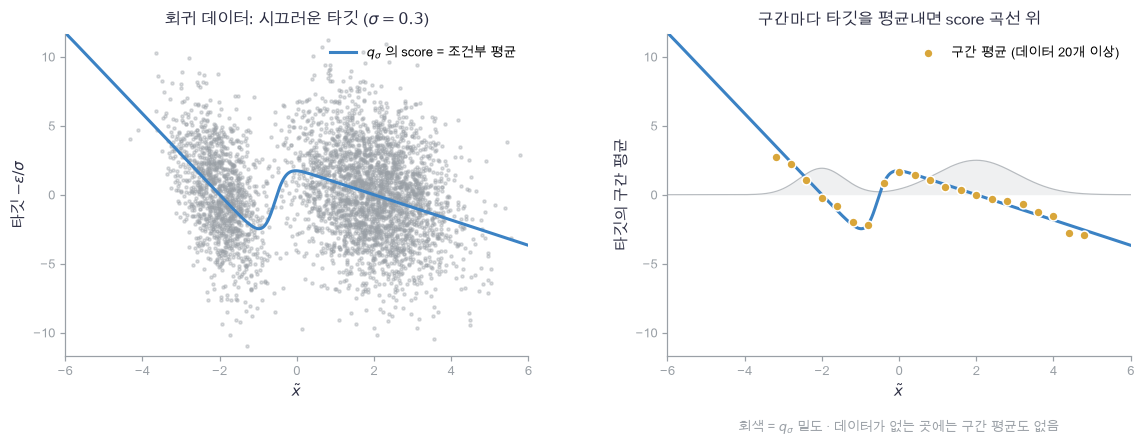

In [27]:
plot_dsm_regression(reg_noisy, reg_target, reg_centers, reg_means, reg_counts, score_x, reg_true, reg_pdf, train_sigma)

🔍 **확인** · 왼쪽 산점은 위아래로 $\pm1/\sigma\approx\pm3$ 넓게 흩어져 있어 점 하나만 보면 정답이 없어 보입니다. 그러나 오른쪽에서 구간마다 평균을 내면(금색) 파란 $q_\sigma$ score 곡선 위에 놓입니다. 회귀는 이 평균을 배웁니다. 데이터가 없는 봉우리 사이와 바깥에는 구간 평균도 없습니다. 거기서는 배울 근거가 없습니다.

아래 구현은 03번의 2층 MLP를 score 모델로 쓴 forward·backward, DSM 손실, 04번 6절의 Adam, 그리고 01b번의 미니배치 루프입니다.

> **코드**
>
> - `{key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}`: 파라미터마다 Adam 상태 (m, v)를 0으로 만든 사전 (05번 5절).
> - `rng.choice(len(X), batch, replace=False)`: 겹치지 않게 뽑은 미니배치 번호 (01b번 3절).

In [28]:
def init_score_model(D, hidden, seed):
    """score 모델 파라미터: W1 (D, hidden), b1 (hidden,), W2 (hidden, D), b2 (D,). 표준편차 1/√입력 으로 두어 층 출력의 크기를 입력 수와 무관하게 만듭니다."""
    rng_init = np.random.default_rng(seed)
    return {"W1": rng_init.normal(size=(D, hidden)) / np.sqrt(D), "b1": np.zeros(hidden),
            "W2": rng_init.normal(size=(hidden, D)) / np.sqrt(hidden), "b2": np.zeros(D)}


def score_forward(X, p):
    """score 모델 forward: H = tanh(X W1 + b1), S = H W2 + b2. X: (N, D) → (S: (N, D), cache: (X, H))."""
    H = np.tanh(X @ p["W1"] + p["b1"])                                # (N, hidden)
    S = H @ p["W2"] + p["b2"]                                         # (N, D)
    return S, (X, H)

In [29]:
def score_backward(dS, cache, p):
    """score 모델 backward (03번 5절): dW2 = Hᵀ dS, db2 = Σ dS, dH = dS W2ᵀ, dZ = dH ⊙ (1 − H²), dW1 = Xᵀ dZ, db1 = Σ dZ.
    dS: (N, D), cache: score_forward 의 것 → grads: p 와 같은 키의 사전."""
    X, H = cache
    dH = dS @ p["W2"].T                                               # (N, hidden)
    dZ = dH * (1 - H ** 2)                                            # tanh 의 도함수 1 − H²
    return {"W1": X.T @ dZ, "b1": dZ.sum(axis=0), "W2": H.T @ dS, "b2": dS.sum(axis=0)}


def dsm_loss(S, eps, sigma):
    """DSM 손실 J = mean_n ‖S_n + ε_n/σ‖² 와 출력 기울기 ∂J/∂S = 2(S + ε/σ)/N. S, eps: (N, D) → (J: 숫자, dS: (N, D))."""
    residual = S + eps / sigma                                        # (N, D): 예측 − 타깃 (타깃 = −ε/σ)
    return float(np.mean(np.sum(residual ** 2, axis=1))), 2 * residual / len(S)

In [30]:
def adam_step(p, grads, state, step, lr):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p 를 제자리에서 바꾸고 state 의 (m, v)를 갱신합니다."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                                # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2                       # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)


def train_score_model(X, sigma, steps, seed, batch=500, hidden=64, lr=3e-3):
    """DSM 으로 score 모델 학습: 스텝마다 미니배치를 뽑고 새 잡음 ε 으로 x̃ = x + σε, 타깃 −ε/σ 를 만들어 Adam 한 걸음.
    X: (N, D) 깨끗한 데이터 → (p: 파라미터 사전, history: 스텝별 손실 (steps,))."""
    p = init_score_model(X.shape[1], hidden, seed)
    state = {key: (np.zeros_like(value), np.zeros_like(value)) for key, value in p.items()}   # Adam 상태 (m, v)
    rng_train = np.random.default_rng(seed + 1)
    history = []
    for step in range(1, steps + 1):
        X_batch = X[rng_train.choice(len(X), batch, replace=False)]   # (batch, D): 미니배치
        eps = rng_train.normal(size=X_batch.shape)                    # (batch, D): 스텝마다 새 잡음
        S, cache = score_forward(X_batch + sigma * eps, p)            # 잡음 낀 입력 → 예측 score
        loss, dS = dsm_loss(S, eps, sigma)
        adam_step(p, score_backward(dS, cache, p), state, step, lr)
        history.append(loss)
    return p, np.array(history)

In [31]:
# 쓰는 것: rng (1절 검산 셀)
probe_p = init_score_model(2, 8, 4)                                   # 작은 2차원 모델 (은닉 8)
probe_Xn = rng.normal(size=(5, 2))                                    # (5, 2): 검사용 잡음 낀 입력
probe_eps = rng.normal(size=(5, 2))                                   # (5, 2): 검사용 잡음
probe_S, probe_cache = score_forward(probe_Xn, probe_p)
probe_loss, probe_dS = dsm_loss(probe_S, probe_eps, 0.5)
probe_grads = score_backward(probe_dS, probe_cache, probe_p)


def dsm_scalar():
    """검사기용: 현재 파라미터의 DSM 손실 (같은 입력·잡음)."""
    return dsm_loss(score_forward(probe_Xn, probe_p)[0], probe_eps, 0.5)[0]


mlp_errors = {key: rel_error(probe_grads[key], numerical_gradient(dsm_scalar, value)) for key, value in probe_p.items()}   # 파라미터마다 상대오차
assert max(mlp_errors.values()) < 1e-6, "네 파라미터의 기울기가 중심차분과 1e−6 안에서 같아야 합니다"
hand_loss, hand_dS = dsm_loss(np.array([[0.5], [-1.]]), np.array([[1.], [-1.]]), 0.5)
np.testing.assert_allclose(hand_loss, 7.625)                          # 검산: 손계산 (2.5² + 3²)/2
np.testing.assert_allclose(hand_dS, [[2.5], [-3.]])                   # 검산: 손계산 2(S + ε/σ)/N
print("score 모델 gradcheck 최대 상대오차:", max(mlp_errors.values()), "· 손계산 손실", hand_loss)

score 모델 gradcheck 최대 상대오차: 1.1548698722086715e-09 · 손계산 손실 7.625


🔍 **확인** · 네 파라미터 모두 중심차분과 $10^{-6}$ 안에서 맞고 손계산 손실·기울기도 맞습니다. 이제 1차원 혼합 데이터로 2,000스텝 학습합니다. 평가는 손실이 아니라 격자 위 닫힌식 $q_\sigma$ score와의 거리($q_\sigma$로 가중한 RMS)로 하고, 세 구간(봉우리 근처·봉우리 사이·바깥)의 오차를 따로 잽니다. 이것은 학습용 작은 문제의 성능이며 실제 벤치마크로 읽지 마세요.

> **코드** · `np.convolve(score_history, np.ones(50) / 50, mode="valid")`: 이웃한 50개의 평균을 한 칸씩 옮겨 가며 냅니다(이동평균). 미니배치 손실의 들쭉날쭉함을 지워 내림세를 보려고 그림에만 씁니다. `mode="valid"`라 앞의 49칸은 값이 없어 `np.nan`으로 둡니다.

In [32]:
def weighted_rms(a, b, weights):
    """가중 RMS 오차 √(Σ w (a − b)² / Σ w). a, b, weights: (N,) → 숫자."""
    return float(np.sqrt(np.sum(weights * (a - b) ** 2) / np.sum(weights)))


def region_masks(x, regions):
    """구간 사전 {이름: [(lo, hi), …]} 을 격자 x 위의 불리언 마스크 목록으로. → [(N,) bool] (이름 순서)."""
    masks = []
    for intervals in regions.values():
        mask = np.zeros_like(x, dtype=bool)
        for lo, hi in intervals:
            mask |= (x >= lo) & (x < hi)
        masks.append(mask)
    return masks

In [33]:
# 쓰는 것: train_x, train_sigma, reg_true, reg_pdf (4절 계산 셀) · score_x (1절 계산 셀) · init_score_model, score_forward, train_score_model, weighted_rms, region_masks (4절)
score_p0 = init_score_model(1, 64, 320)                               # 학습 전 파라미터 (학습과 같은 seed)
score_p, score_history = train_score_model(train_x[:, None], train_sigma, 2000, 320)
smooth_window = 50
score_smooth = np.full(len(score_history), np.nan)                   # (2000,): 앞 49칸은 평균을 낼 수 없어 비워 둡니다
score_smooth[smooth_window - 1:] = np.convolve(score_history, np.ones(smooth_window) / smooth_window, mode="valid")   # 이동평균
learned_before = score_forward(score_x[:, None], score_p0)[0][:, 0]  # (1201,): 학습 전 s_θ
learned_after = score_forward(score_x[:, None], score_p)[0][:, 0]    # (1201,): 학습 후 s_θ
rms_before = weighted_rms(learned_before, reg_true, reg_pdf)
rms_after = weighted_rms(learned_after, reg_true, reg_pdf)
score_regions = {"봉우리 근처": [(-3., -1.), (0.5, 3.5)], "봉우리 사이": [(-1., 0.5)], "바깥": [(-6., -3.5), (4.5, 6.)]}
score_masks = region_masks(score_x, score_regions)
region_errors = [float(np.sqrt(np.mean((learned_after - reg_true)[mask] ** 2))) for mask in score_masks]   # 구간별 RMS (가중 없음)
assert rms_after < 0.3, "학습 뒤 q_σ 가중 RMS 오차가 0.3 아래여야 합니다"
assert rms_after < rms_before / 3, "학습 뒤 가중 RMS 오차가 학습 전의 1/3 아래여야 합니다"
assert region_errors[2] > 5 * region_errors[0], "데이터가 없는 바깥의 오차가 봉우리 근처의 5 배보다 커야 합니다"
print(f"DSM 손실 {score_history[0]:.3f} → {score_history[-100:].mean():.3f} (최솟값이 0 이 아님) · q_σ 가중 RMS 오차 {rms_before:.3f} → {rms_after:.3f}")
print("구간별 RMS 오차 (근처 / 사이 / 바깥):", np.round(region_errors, 3))

DSM 손실 11.244 → 9.683 (최솟값이 0 이 아님) · q_σ 가중 RMS 오차 1.432 → 0.108
구간별 RMS 오차 (근처 / 사이 / 바깥): [0.081 0.177 2.735]


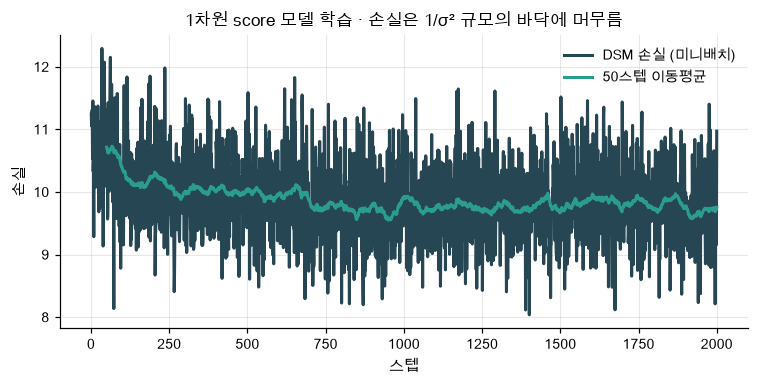

In [34]:
# 쓰는 것: score_history, score_smooth (4절 학습 셀)
plot_curves(np.arange(1, 2001), {"DSM 손실 (미니배치)": score_history, "50스텝 이동평균": score_smooth},
            title="1차원 score 모델 학습 · 손실은 1/σ² 규모의 바닥에 머무름", ylabel="손실")

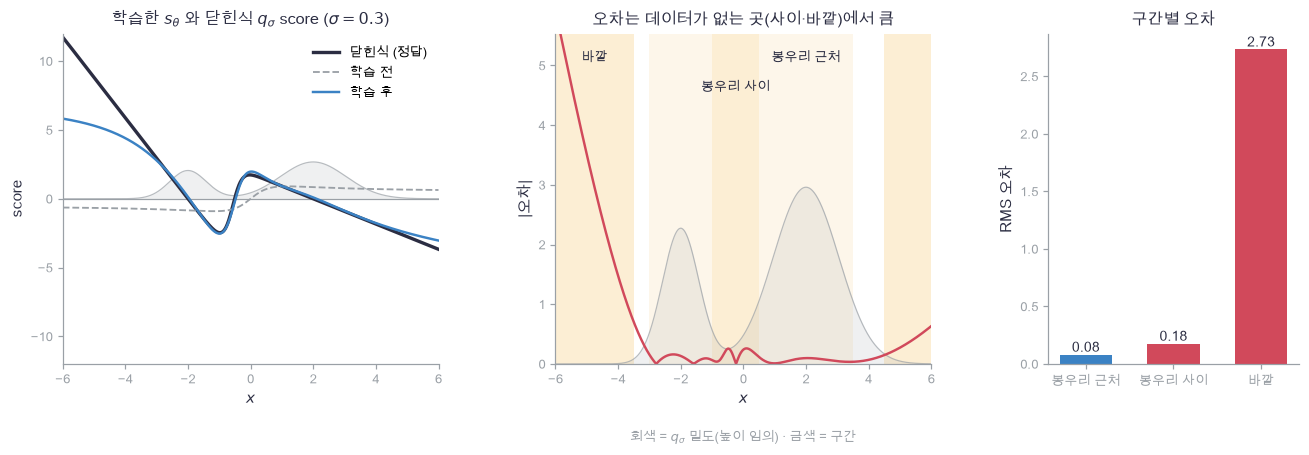

In [35]:
plot_learned_score_1d(score_x, reg_pdf, reg_true, learned_before, learned_after, score_regions, region_errors, train_sigma)

🔍 **확인** · 미니배치 손실 자체는 8.0–12.3 사이로 흔들려 내림세가 보이지 않지만, 50스텝 이동평균 곡선은 10.7에서 9.8로 내려가 멈춥니다(첫 스텝 11.244, 마지막 100스텝 평균 9.683). 위에서 말한 바닥 $\mathbb E[\mathrm{Var}(\epsilon/\sigma\mid\tilde x)]$입니다. 그런데도 왼쪽 그림에서 학습 후 곡선(파랑)은 봉우리 근처에서 닫힌식(검정)과 겹칩니다. 가중 RMS 오차는 1.432에서 0.108로 내려갔습니다.
가운데 오차 곡선은 데이터가 거의 없는 바깥에서 압도적으로 큽니다(오른쪽 막대). 거기서는 회귀 데이터가 없어 무엇을 내도 손실이 변하지 않습니다. 봉우리 사이는 $\sigma$에 따라 달라집니다. $\sigma=0.3$에서는 근처보다 크지만, 완성 예제의 $\sigma=1.0$에서는 잡음이 사이까지 데이터를 옮겨 놓아 오히려 작아집니다. 이것이 33번에서 잡음 수준을 여러 개 두는 이유입니다. 큰 $\sigma$에서는 어디에나 데이터가 있습니다.

같은 코드로 2차원 혼합도 학습합니다. 입력·출력 차원만 2가 됩니다.

In [36]:
# 쓰는 것: rng (1절 검산 셀) · mix2_sample, mix2_logpdf (📎 혼합 셀) · field_X, field_xx, field_yy, dense_xx, dense_yy (1절 계산 셀) · mix2_score_noisy (3절) · train_sigma (4절 계산 셀) · init_score_model, score_forward, train_score_model (4절)
train_X2 = mix2_sample(4000, rng)                                      # (4000, 2): 2차원 학습 데이터
score_p2, score_history2 = train_score_model(train_X2, train_sigma, 2000, 321)
field_true2 = mix2_score_noisy(field_X, train_sigma)                   # (204, 2): 화살표 격자의 닫힌식 q_σ score
field_learned2 = score_forward(field_X, score_p2)[0]                   # (204, 2): 학습한 벡터장
dense_X = np.column_stack([dense_xx.ravel(), dense_yy.ravel()])        # (10285, 2): 촘촘한 격자
dense_true2 = mix2_score_noisy(dense_X, train_sigma)
dense_learned2 = score_forward(dense_X, score_p2)[0]
dense_error2 = np.linalg.norm(dense_learned2 - dense_true2, axis=1).reshape(dense_xx.shape)   # (85, 121): 오차 크기
dense_q2 = np.exp(mix2_logpdf(dense_X, train_sigma))                   # (10285,): q_σ 밀도 (가중치)
dense_before2 = score_forward(dense_X, init_score_model(2, 64, 321))[0]
rms2_before = float(np.sqrt(np.sum(dense_q2 * np.sum((dense_before2 - dense_true2) ** 2, axis=1)) / dense_q2.sum()))
rms2_after = float(np.sqrt(np.sum(dense_q2 * np.sum((dense_learned2 - dense_true2) ** 2, axis=1)) / dense_q2.sum()))
dense_pdf2 = dense_q2.reshape(dense_xx.shape)
assert rms2_after < 0.6, "2차원에서도 학습 뒤 q_σ 가중 RMS 오차가 0.6 아래여야 합니다"
assert rms2_after < rms2_before / 3, "2차원에서도 학습 뒤 가중 RMS 오차가 학습 전의 1/3 아래여야 합니다"
high_density = dense_q2 > 0.2 * dense_q2.max()                         # 데이터가 많은 곳
low_density = dense_q2 < 0.01 * dense_q2.max()                         # 데이터가 거의 없는 곳
assert np.mean(dense_error2.ravel()[high_density]) < np.mean(dense_error2.ravel()[low_density]), "데이터가 많은 곳의 오차가 없는 곳보다 작아야 합니다"
print(f"2차원 DSM 손실 {score_history2[0]:.3f} → {score_history2[-100:].mean():.3f} · q_σ 가중 RMS 오차 {rms2_before:.3f} → {rms2_after:.3f}")
print("평균 오차: 밀도 높은 곳", np.mean(dense_error2.ravel()[high_density]).round(3), "· 밀도 낮은 곳", np.mean(dense_error2.ravel()[low_density]).round(3))

2차원 DSM 손실 28.617 → 19.028 · q_σ 가중 RMS 오차 2.844 → 0.230
평균 오차: 밀도 높은 곳 0.151 · 밀도 낮은 곳 1.655


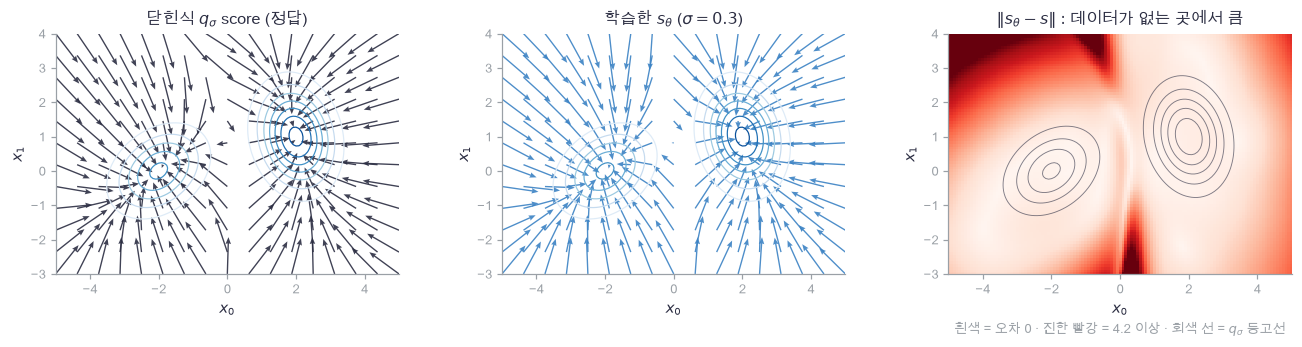

In [37]:
plot_learned_field_2d(field_xx, field_yy, field_true2, field_learned2, dense_xx, dense_yy, dense_pdf2, dense_error2, train_sigma)

🔍 **확인** · 가운데의 학습한 벡터장이 왼쪽 닫힌식과 등고선 안에서 같은 방향을 가리킵니다. 오른쪽 오차 지도는 등고선 밖(데이터가 없는 곳)에서만 붉습니다. 1차원과 같은 이야기가 2차원에서도 성립합니다.

### ✏️ 연습 4 · DSM 손실과 출력 기울기

예측 `S` `(N, D)`, 잡음 `eps` `(N, D)`, `sigma`에서 손실 $J=\frac1N\sum_n\|S_n+\epsilon_n/\sigma\|^2$와 출력 기울기 $\partial J/\partial S=\frac2N(S+\epsilon/\sigma)$ 두 줄을 채우세요. 관측 축은 평균, 좌표 축은 합입니다.

In [38]:

def exercise_dsm_loss(S, eps, sigma):
    """연습 4: DSM 손실과 출력 기울기. S, eps: (N, D), sigma: 숫자 → (loss: 숫자, dS: (N, D))."""
    assert S.shape == eps.shape, "예측과 잡음은 같은 (N, D) 모양이어야 합니다"
    residual = S + eps / sigma                                       # (N, D): 예측 − 타깃
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: loss = residual² 을 좌표 축으로 합한 뒤 관측 축으로 평균한 숫자, dS = 2 × residual / N (모양 (N, D))
    ### 힌트: 4절 dsm_loss 의 두 줄. np.mean(np.sum(residual ** 2, axis=1)), len(S) 가 N 입니다.
    raise NotImplementedError
    return loss, dS

In [39]:

def check_dsm_loss(candidate):
    """4절 손계산, 본문 dsm_loss, 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: dsm_loss (4절)
    loss_hand, dS_hand = candidate(np.array([[0.5], [-1.]]), np.array([[1.], [-1.]]), 0.5)
    np.testing.assert_allclose(loss_hand, 7.625)                                                    # 검산: 손계산 (2.5² + 3²)/2
    np.testing.assert_allclose(dS_hand, [[2.5], [-3.]])                                             # 검산: 손계산 2(S + ε/σ)/2
    S_c = np.random.default_rng(41).normal(size=(6, 2))
    e_c = np.random.default_rng(42).normal(size=(6, 2))
    loss_c, dS_c = candidate(S_c, e_c, 0.4)
    np.testing.assert_allclose([loss_c], [dsm_loss(S_c, e_c, 0.4)[0]])                              # 검산: 본문 dsm_loss 의 손실
    np.testing.assert_allclose(dS_c, dsm_loss(S_c, e_c, 0.4)[1])                                    # 검산: 본문 dsm_loss 의 기울기

    def loss_scalar():
        """검사기용: 후보의 손실값."""
        return float(candidate(S_c, e_c, 0.4)[0])

    assert rel_error(dS_c, numerical_gradient(loss_scalar, S_c)) < 1e-7, "출력 기울기가 중심차분과 1e−7 안에서 같아야 합니다"
    print("DSM 손실과 출력 기울기: 손계산·dsm_loss·중심차분과 일치합니다.")

run_check(check_dsm_loss, exercise_dsm_loss, hint="loss = float(np.mean(np.sum(residual ** 2, axis=1))) · dS = 2 * residual / len(S)")

☐ exercise_dsm_loss: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss = float(np.mean(np.sum(residual ** 2, axis=1))) · dS = 2 * residual / len(S)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss = float(np.mean(np.sum(residual ** 2, axis=1)))
dS = 2 * residual / len(S)
```

</details>

## 🔑 5. score로 점을 옮기기: 오르막과 Langevin 한 걸음

**이 절에서 가져갈 것:** $x\leftarrow x+\frac{\alpha}{2}s(x)$는 로그 밀도의 경사 오르막이라 가까운 봉우리 꼭대기로 갑니다. 여기에 잡음 $\sqrt\alpha\,z$($z\sim\mathcal N(0,1)$)를 더한 Langevin 한 걸음을 오래 반복하면 점들이 꼭대기에 모이지 않고 $p$를 따라 퍼집니다.

배운 score로 무엇을 할까요? 1절의 화살표를 따라 걸으면 봉우리 꼭대기에 도착합니다. 그러나 "샘플"은 꼭대기 하나가 아니라 봉우리 주변에 밀도만큼 흩어져야 합니다. 그래서 걸음마다 잡음을 섞습니다.

> **용어**
>
> - **경사 오르막(gradient ascent)**: 01번의 경사하강을 부호만 바꾼 것. 손실을 내리는 대신 로그 밀도를 올립니다. 걸음 크기는 $\alpha/2$로 씁니다(아래 Langevin과 맞추기 위해).
> - **Langevin dynamics**: $x_{t+1}=x_t+\frac{\alpha}{2}s(x_t)+\sqrt\alpha\,z_t$. 오르막 $\alpha/2$와 잡음 $\sqrt\alpha$의 비율이 이렇게 맞을 때, $\alpha\to0$·반복 $\to\infty$의 극한에서 점의 분포가 정확히 $p$가 됩니다. 33번이 이 걸음을 여러 $\sigma$에 걸쳐 씁니다.
> - **total variation(TV) 거리** $\frac12\sum_b|\hat h_b-p_b|$: 히스토그램 확률과 분포의 구간 확률이 얼마나 다른지. 0이면 같고 1이면 전혀 겹치지 않습니다.

$$\text{오르막: } x_{t+1}=x_t+\frac{\alpha}{2}s(x_t),\qquad
\text{Langevin: } x_{t+1}=x_t+\frac{\alpha}{2}s(x_t)+\sqrt{\alpha}\,z_t,\quad z_t\sim\mathcal N(0,1).$$

$x_t$가 입자 $(M,)$이면 $s(x_t)$와 $z_t$도 $(M,)$이고 모든 입자가 한 줄로 움직입니다. 2차원이면 $(M,2)$입니다.

손계산 $x=0$, $\alpha=0.1$: 오르막 한 걸음은 $0+0.05\times1.979=0.099$. 잡음 $z=1$이면 $0.099+\sqrt{0.1}=0.099+0.316=0.415$.

아래는 출발점 7개의 오르막 200걸음과, $[-6,6]$에 고르게 뿌린 입자 4,000개의 Langevin 3,000걸음입니다. 1절의 정확한 `mix_score`를 씁니다.

> **코드** · `np.histogram(v, edges)[0]`: 구간 경계 `edges`로 나눈 개수 `(len(edges) − 1,)`. 입자 수로 나누면 구간 확률입니다.

In [40]:
# 쓰는 것: mix_score (1절) · mix_logpdf (📎 혼합 셀)
walk_alpha = 0.1
walk_starts = np.array([-4., -1.5, -0.5, 0., 0.5, 3.5, 5.])          # (7,): 출발점
ascent_path = [walk_starts]
for step in range(200):
    ascent_path.append(ascent_path[-1] + walk_alpha / 2 * mix_score(ascent_path[-1]))   # 오르막: x ← x + (α/2) s(x)
ascent_path = np.array(ascent_path)                                   # (201, 7)
walk_rng = np.random.default_rng(3205)
langevin_x = walk_rng.uniform(-6, 6, size=4000)                       # (4000,): 입자를 [−6, 6] 에 고르게
langevin_x[:7] = walk_starts                                          # 처음 7개는 오르막과 같은 출발점 (그림용)
langevin_path = [langevin_x[:7].copy()]
for step in range(3000):
    langevin_x = langevin_x + walk_alpha / 2 * mix_score(langevin_x) + np.sqrt(walk_alpha) * walk_rng.normal(size=4000)   # + √α z
    if step < 150:
        langevin_path.append(langevin_x[:7].copy())
langevin_path = np.array(langevin_path)                               # (151, 7): 처음 150 걸음의 입자 7개 경로
walk_edges = np.linspace(-6, 6, 49)                                   # (49,): 히스토그램 구간 경계 (폭 0.25)
walk_hist = np.histogram(langevin_x, walk_edges)[0] / len(langevin_x)   # (48,): 구간별 입자 비율
walk_centers = 0.5 * (walk_edges[1:] + walk_edges[:-1])
walk_density = np.exp(mix_logpdf(walk_centers)) * 0.25                # (48,): 구간별 p 의 확률 (밀도 × 폭)
walk_tv = 0.5 * np.abs(walk_hist - walk_density).sum()
print("오르막 도착점:", ascent_path[-1].round(3))
print("Langevin 3,000걸음 뒤 x > 0 비율", np.mean(langevin_x > 0).round(3), "(π₂ = 0.7) · 평균", langevin_x.mean().round(3), "(닫힌식 0.8) · TV 거리", walk_tv.round(4))

오르막 도착점: [-2. -2.  2.  2.  2.  2.  2.]
Langevin 3,000걸음 뒤 x > 0 비율 0.691 (π₂ = 0.7) · 평균 0.829 (닫힌식 0.8) · TV 거리 0.0349


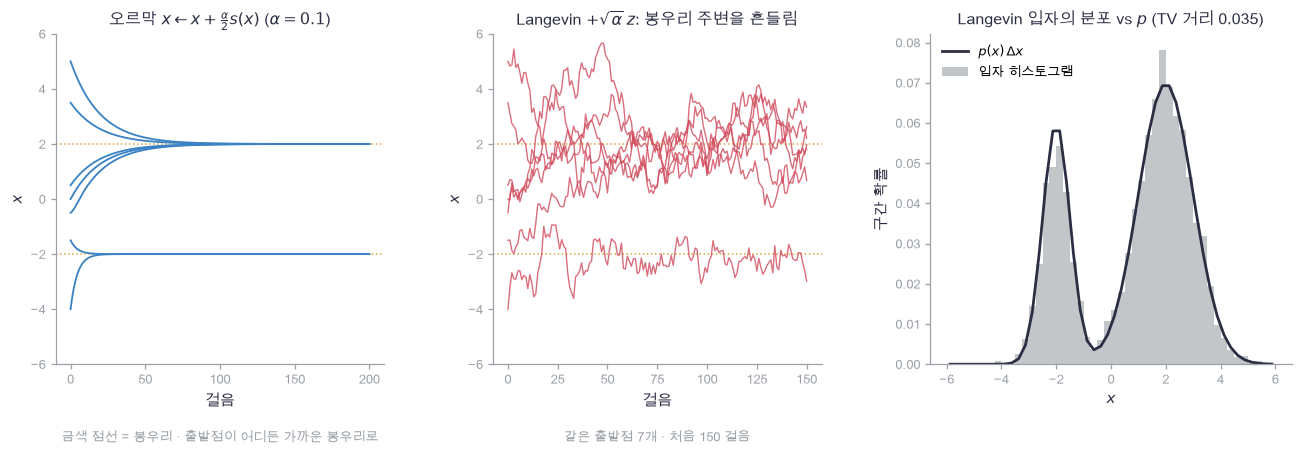

In [41]:
plot_dynamics(ascent_path, langevin_path, score_modes, score_x, score_pdf, walk_edges, walk_hist, walk_density, walk_tv, walk_alpha)

🔍 **확인** · 왼쪽 오르막 경로는 출발점이 어디든 가까운 봉우리($-2$ 또는 $2$)에 멈춥니다. 봉우리 사이에서 출발한 $x=-1.5$와 $x=-0.5$는 밀도의 골($x\approx-0.6$)을 기준으로 갈라져 각각 왼쪽·오른쪽 봉우리로 갑니다. 가운데 Langevin 경로는 같은 출발점에서 봉우리 근처를 흔들리며 돌아다니고, 골을 넘어 반대 봉우리로 가는 일은 드뭅니다. 오른쪽 히스토그램은 3,000걸음 뒤 $p$와 TV 거리 0.04 안에서 겹치며, 오른쪽 봉우리의 비율도 $\pi_2=0.7$에 가깝습니다. 출발은 반반이었는데 골을 넘는 입자가 있어 비율이 맞춰집니다.

아래 구현은 한 걸음 함수 둘과 오르막 반복이고, 검산은 손계산, 로그 밀도의 단조 증가, 잡음 크기 $\sqrt\alpha$, 위 히스토그램과 $p$의 TV 거리, 그리고 $p$의 샘플로 시작한 Langevin이 $p$에 머무는지(정상성)를 봅니다.

In [42]:
def ascent_step(x, score_fn, alpha):
    """경사 오르막 한 걸음 x + (α/2) s(x). x: (M,) 또는 (M, D), score_fn: x → 같은 모양 → 같은 모양."""
    return x + alpha / 2 * score_fn(x)


def langevin_step(x, score_fn, alpha, rng):
    """Langevin 한 걸음 x + (α/2) s(x) + √α z, z ~ N(0, I). x: (M,) 또는 (M, D) → 같은 모양."""
    return x + alpha / 2 * score_fn(x) + np.sqrt(alpha) * rng.normal(size=x.shape)


def run_ascent(x0, score_fn, alpha, steps):
    """오르막을 steps 번 반복한 경로. x0: (M,) → (steps + 1, M)."""
    path = [x0]
    for step in range(steps):
        path.append(ascent_step(path[-1], score_fn, alpha))
    return np.array(path)

In [43]:
# 쓰는 것: mix_score (1절) · mix_logpdf, mix_sample (📎 혼합 셀) · walk_starts, walk_alpha, ascent_path, walk_edges, walk_density, walk_tv, langevin_x (5절 계산 셀)
np.testing.assert_allclose(ascent_step(np.array([0.]), mix_score, 0.1), [0.0989], atol=1e-4)   # 검산: 손계산 0.05 × 1.979
check_path = run_ascent(walk_starts, mix_score, walk_alpha, 200)
np.testing.assert_allclose(check_path, ascent_path)                    # 검산: 위 그림의 경로와 같음
logp_path = mix_logpdf(check_path.ravel()).reshape(check_path.shape)   # (201, 7): 걸음마다 log p
assert np.all(np.diff(logp_path, axis=0) >= -1e-12), "오르막에서 log p 는 걸음마다 내려가지 않아야 합니다"
assert np.all(np.abs(mix_score(check_path[-1])) < 1e-3), "200 걸음 뒤에는 봉우리(score ≈ 0)에 있어야 합니다"
check_rng = np.random.default_rng(3206)
walk_zero_x = np.zeros(4000)                                          # (4000,): 잡음 부분만 재려고 모두 0 에서 출발
noise_part = langevin_step(walk_zero_x, mix_score, 0.1, check_rng) - ascent_step(walk_zero_x, mix_score, 0.1)   # (4000,): 걸음의 잡음 부분
np.testing.assert_allclose(noise_part.std(), np.sqrt(0.1), rtol=0.05)   # 검산: 잡음의 표준편차 = √α
stationary_x = mix_sample(4000, check_rng)                            # (4000,): p 의 샘플로 시작
for step in range(300):
    stationary_x = langevin_step(stationary_x, mix_score, walk_alpha, check_rng)
stationary_hist = np.histogram(stationary_x, walk_edges)[0] / 4000
stationary_tv = 0.5 * np.abs(stationary_hist - walk_density).sum()
assert stationary_tv < 0.06, "p 의 샘플로 시작한 Langevin 은 300 걸음 뒤에도 p 근처(TV < 0.06)에 있어야 합니다"
np.testing.assert_allclose(stationary_x.mean(), 0.8, atol=0.1)         # 검산: 평균 Σ π_k μ_k = 0.8 유지
assert walk_tv < 0.08, "고르게 뿌린 입자의 3,000 걸음 뒤 히스토그램이 p 와 TV 0.08 안이어야 합니다"
np.testing.assert_allclose(np.mean(langevin_x > 0), 0.7, atol=0.05)    # 검산: 오른쪽 봉우리의 비율 = π₂
print("오르막: log p 단조 증가, 도착점 score 최대 |s| =", np.abs(mix_score(check_path[-1])).max().round(6))
print("Langevin 잡음 표준편차", noise_part.std().round(4), "(√α = 0.3162) · p 에서 출발한 300 걸음 뒤 TV 거리", stationary_tv.round(4),
      "· 위 그림(고르게 뿌린 입자) 의 TV 거리", walk_tv.round(4))

오르막: log p 단조 증가, 도착점 score 최대 |s| = 0.000105
Langevin 잡음 표준편차 0.3112 (√α = 0.3162) · p 에서 출발한 300 걸음 뒤 TV 거리 0.0329 · 위 그림(고르게 뿌린 입자) 의 TV 거리 0.0349


🔍 **확인** · 오르막은 손계산 한 걸음과 맞고, 200걸음 동안 로그 밀도가 한 번도 내려가지 않으며 도착점의 score는 $10^{-3}$ 아래입니다. Langevin 걸음의 잡음 부분은 표준편차 $\sqrt\alpha$이고, 위 히스토그램은 $p$와 TV 0.08 안이며 오른쪽 봉우리의 비율도 $\pi_2=0.7$ 근처입니다. $p$의 샘플로 시작하면 300걸음 뒤에도 $p$에 머뭅니다(정상성).

📎 이 절은 정확한 `mix_score`를 썼습니다. 4절의 학습된 $s_\theta$로 바꾸면 봉우리 근처에서는 같은 걸음이지만, 데이터가 없는 곳에서 출발한 입자는 틀린 화살표를 따릅니다. 큰 $\sigma$의 score부터 시작해 작은 $\sigma$로 내려오는 annealed Langevin이 33번의 답입니다.

### ✏️ 연습 5 · Langevin 한 걸음

입자 `x` `(M,)`, 그 자리의 score 값 `score` `(M,)`, 걸음 크기 `alpha`, 표준정규 잡음 `z` `(M,)`에서 Langevin 한 걸음 $x+\frac{\alpha}{2}s+\sqrt\alpha\,z$ 한 줄을 채우세요. 본문 `langevin_step`은 score 함수와 난수 생성기를 받았지만, 여기서는 값이 이미 주어집니다.

In [44]:

def exercise_langevin_step(x, score, alpha, z):
    """연습 5: Langevin 한 걸음. x, score, z: (M,), alpha: 숫자 → x_next: (M,)."""
    assert x.shape == score.shape == z.shape, "입자·score·잡음은 같은 모양이어야 합니다"
    assert alpha > 0, "걸음 크기는 양수여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: x_next = x + (alpha/2) × score + √alpha × z (모양 (M,))
    ### 힌트: 5절 langevin_step 의 한 줄에서 score_fn(x) 가 score, rng.normal(...) 이 z 입니다.
    raise NotImplementedError
    return x_next

In [45]:

def check_langevin_step(candidate):
    """5절 손계산(x = 0, α = 0.1, z = 1 → 0.415), z = 0 이면 오르막, 본문 langevin_step 과 같은 잡음으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mix_score (1절) · ascent_step, langevin_step (5절)
    np.testing.assert_allclose(candidate(np.array([0.]), np.array([1.9788]), 0.1, np.array([1.])), [0.4152], atol=1e-4)   # 검산: 손계산 0.099 + 0.316
    x_c = np.random.default_rng(51).uniform(-4, 4, size=5)
    np.testing.assert_allclose(candidate(x_c, mix_score(x_c), 0.1, np.zeros(5)), ascent_step(x_c, mix_score, 0.1))        # 검산: z = 0 이면 오르막 한 걸음
    z_c = np.random.default_rng(52).normal(size=5)
    np.testing.assert_allclose(candidate(x_c, mix_score(x_c), 0.1, z_c), langevin_step(x_c, mix_score, 0.1, np.random.default_rng(52)))   # 검산: 같은 seed 의 잡음이면 본문 함수와 같음
    print("Langevin 한 걸음: 손계산·오르막·langevin_step 과 일치합니다.")

run_check(check_langevin_step, exercise_langevin_step, hint="x_next = x + alpha / 2 * score + np.sqrt(alpha) * z")

☐ exercise_langevin_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x_next = x + alpha / 2 * score + np.sqrt(alpha) * z


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x_next = x + alpha / 2 * score + np.sqrt(alpha) * z
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 잡음 낀 혼합 $q_\sigma$의 score (3절)

`x` `(N,)`와 잡음 크기 `sigma`에서 $\nabla\log q_\sigma(x)=\sum_kr_k^\sigma(x)(\mu_k-x)/(\sigma_k^2+\sigma^2)$ 한 줄을 채우세요. 책임확률 `r`은 📎 셀의 `mix_responsibility(x, sigma)`로 미리 구해 두었습니다.

In [46]:
def exercise_noisy_score(x, sigma):
    """연습 A: q_σ 의 score. x: (N,), sigma: 숫자 → score: (N,)."""
    variances = MIX_SIGMA ** 2 + sigma ** 2                          # (2,): 성분 분산 σ_k² + σ²
    r = mix_responsibility(x, sigma)                                 # (N, 2): q_σ 의 책임확률
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: score = r 로 가중한 (MIX_MU − x)/variances 의 성분 축 합 (모양 (N,))
    ### 힌트: 1절 mix_score 의 한 줄에서 MIX_SIGMA ** 2 를 variances 로. x[:, None] 으로 세워 브로드캐스팅합니다.
    raise NotImplementedError
    return score

In [47]:
def check_noisy_score(candidate):
    """3절 손계산(σ = 1, x = 0 → 0.404), σ = 0 이면 1절 score, 본문 mix_score_noisy 로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mix_score (1절) · mix_score_noisy (3절)
    np.testing.assert_allclose(candidate(np.array([0.]), 1.0), [0.4038], atol=1e-4)                # 검산: 3절 손계산
    x_c = np.random.default_rng(61).uniform(-5, 5, size=7)
    np.testing.assert_allclose(candidate(x_c, 0.0), mix_score(x_c))                                # 검산: σ = 0 이면 원래 score
    for sigma in [0.3, 1.0]:
        np.testing.assert_allclose(candidate(x_c, sigma), mix_score_noisy(x_c, sigma))             # 검산: 본문 함수와 같음
    assert np.abs(candidate(x_c, 2.0)).max() < np.abs(candidate(x_c, 0.1)).max(), "σ 가 크면 score 가 완만해야 합니다"
    print("q_σ 의 score: 손계산·mix_score_noisy 와 일치합니다.")

run_check(check_noisy_score, exercise_noisy_score, hint="score = np.sum(r * (MIX_MU - x[:, None]) / variances, axis=1)")

☐ exercise_noisy_score: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: score = np.sum(r * (MIX_MU - x[:, None]) / variances, axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
score = np.sum(r * (MIX_MU - x[:, None]) / variances, axis=1)
```

</details>

### ✏️ 연습 B · score 모델 backward의 tanh 층 (4절)

출력 기울기 `dS` `(N, D)`와 캐시 `(X, H)`에서 두 번째 층의 기울기 `dW2`, `db2`는 써 두었습니다. 은닉으로 되돌아가는 $dH=dS\,W_2^\top$과 tanh의 도함수를 곱한 $dZ=dH\odot(1-H^2)$ 두 줄을 채우세요. 나머지 $dW_1=X^\top dZ$, $db_1$도 써 두었습니다.

In [48]:
def exercise_score_backward(dS, cache, p):
    """연습 B: score 모델 backward. dS: (N, D), cache: (X, H), p: 파라미터 사전 → grads: 같은 키의 사전."""
    X, H = cache
    dW2, db2 = H.T @ dS, dS.sum(axis=0)                              # 두 번째 층 (03번 5절)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dH = dS 를 W2 의 전치로 되돌린 (N, hidden), dZ = dH ⊙ (1 − H²) (N, hidden)
    ### 힌트: 4절 score_backward 의 두 줄. p["W2"].T, 1 - H ** 2
    raise NotImplementedError
    return {"W1": X.T @ dZ, "b1": dZ.sum(axis=0), "W2": dW2, "b2": db2}

In [49]:
def check_score_backward(candidate):
    """4절 검산 셀의 작은 모델에서 본문 score_backward 와 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: probe_p, probe_Xn, probe_eps, probe_cache, probe_dS, probe_grads (4절 검산 셀) · score_forward, dsm_loss (4절)
    grads_c = candidate(probe_dS, probe_cache, probe_p)
    for key in probe_p:
        np.testing.assert_allclose(grads_c[key], probe_grads[key])                                  # 검산: 본문 score_backward 와 같음

    def loss_c():
        """검사기용: 현재 파라미터의 DSM 손실."""
        return dsm_loss(score_forward(probe_Xn, probe_p)[0], probe_eps, 0.5)[0]

    assert rel_error(grads_c["W1"], numerical_gradient(loss_c, probe_p["W1"])) < 1e-6, "dW1 이 중심차분과 1e−6 안에서 같아야 합니다"
    assert rel_error(grads_c["b1"], numerical_gradient(loss_c, probe_p["b1"])) < 1e-6, "db1 이 중심차분과 1e−6 안에서 같아야 합니다"
    print("score 모델 backward: score_backward·중심차분과 일치합니다.")

run_check(check_score_backward, exercise_score_backward, hint="dH = dS @ p[\"W2\"].T · dZ = dH * (1 - H ** 2)")

☐ exercise_score_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dH = dS @ p["W2"].T · dZ = dH * (1 - H ** 2)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dH = dS @ p["W2"].T
dZ = dH * (1 - H ** 2)
```

</details>

### ✏️ 연습 C · Tweedie 항등으로 score 만들기 (3절)

잡음 낀 점 `x_noisy` `(N,)`와 `sigma`에서, 23번의 최적 복원 `mix_denoiser`만으로 $q_\sigma$의 score $(\mathbb E[x\mid\tilde x]-\tilde x)/\sigma^2$ 한 줄을 채우세요. 책임확률을 다시 쓰지 않고 denoiser에서 score를 얻는 방향입니다(34·35b가 쓰는 변환).

In [50]:
def exercise_tweedie_score(x_noisy, sigma):
    """연습 C: Tweedie 항등 score = (E[x | x̃] − x̃)/σ². x_noisy: (N,), sigma: 숫자 → (N,)."""
    assert sigma > 0, "잡음 크기는 양수여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: score = (mix_denoiser(x_noisy, sigma) − x_noisy) / sigma² (모양 (N,))
    ### 힌트: 3절 검산 셀의 Tweedie 줄.
    raise NotImplementedError
    return score

In [51]:
def check_tweedie_score(candidate):
    """3절 손계산(σ = 1, x̃ = 0), 본문 mix_score_noisy, log q_σ 의 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mix_score_noisy (3절) · mix_logpdf (📎 혼합 셀)
    np.testing.assert_allclose(candidate(np.array([0.]), 1.0), [0.4038], atol=1e-4)               # 검산: 3절 손계산 (0.4038 − 0)/1
    x_c = np.random.default_rng(71).uniform(-5, 5, size=7)
    for sigma in [0.3, 1.0, 2.0]:
        np.testing.assert_allclose(candidate(x_c, sigma), mix_score_noisy(x_c, sigma), atol=1e-10)   # 검산: 책임확률 가중합으로 만든 score 와 같음

    def logq_c():
        """검사기용: 검사 점들의 log q_σ (σ = 0.6) 합."""
        return float(np.sum(mix_logpdf(x_c, 0.6)))

    assert rel_error(candidate(x_c, 0.6), numerical_gradient(logq_c, x_c)) < 1e-7, "중심차분과 1e−7 안에서 같아야 합니다"
    print("Tweedie score: 손계산·mix_score_noisy·중심차분과 일치합니다.")

run_check(check_tweedie_score, exercise_tweedie_score, hint="score = (mix_denoiser(x_noisy, sigma) - x_noisy) / sigma ** 2")

☐ exercise_tweedie_score: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: score = (mix_denoiser(x_noisy, sigma) - x_noisy) / sigma ** 2


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
score = (mix_denoiser(x_noisy, sigma) - x_noisy) / sigma ** 2
```

</details>

### ✏️ 연습 D · 오르막 반복 (5절)

출발점 `x0` `(M,)`에서 `steps`번 오르막을 반복해 마지막 위치를 돌려줍니다. 반복문은 써 두었으니 한 걸음 $x\leftarrow x+\frac{\alpha}{2}\,s(x)$ 한 줄을 채우세요. score는 1절의 `mix_score`를 씁니다.

In [52]:
def exercise_ascent(x0, alpha, steps):
    """연습 D: 오르막 steps 번 반복. x0: (M,), alpha: 숫자 → x: (M,) 마지막 위치."""
    assert alpha > 0, "걸음 크기는 양수여야 합니다"
    x = x0.copy()                                                    # 출발점을 바꾸지 않도록 복사
    for step in range(steps):
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: x = x + (alpha/2) × mix_score(x)
        ### 힌트: 5절 ascent_step 의 한 줄 (score_fn 은 mix_score).
        raise NotImplementedError
    return x

In [53]:
def check_ascent(candidate):
    """5절 그림의 경로 끝, 봉우리 도착(score ≈ 0), log p 증가, 1 걸음 손계산으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: walk_starts, walk_alpha, ascent_path (5절 계산 셀) · mix_score (1절) · mix_logpdf (📎 혼합 셀)
    np.testing.assert_allclose(candidate(np.array([0.]), 0.1, 1), [0.0989], atol=1e-4)            # 검산: 손계산 한 걸음 0.05 × 1.979
    np.testing.assert_allclose(candidate(walk_starts, walk_alpha, 200), ascent_path[-1])           # 검산: 5절 그림의 도착점
    x_c = np.random.default_rng(81).uniform(-5, 5, size=6)
    x_end = candidate(x_c, 0.1, 300)
    assert np.all(np.abs(mix_score(x_end)) < 1e-3), "300 걸음 뒤에는 봉우리(score ≈ 0)에 있어야 합니다"
    assert np.all(mix_logpdf(x_end) >= mix_logpdf(x_c)), "도착점의 log p 가 출발점보다 작으면 안 됩니다"
    print("오르막 반복: 손계산·5절 경로와 일치하고 봉우리에 도착합니다.")

run_check(check_ascent, exercise_ascent, hint="x = x + alpha / 2 * mix_score(x)")

☐ exercise_ascent: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: x = x + alpha / 2 * mix_score(x)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
x = x + alpha / 2 * mix_score(x)
```

</details>

### 🔍 완성 예제 · 잡음 크기 $\sigma$를 0.1과 1.0으로 바꿔 학습

4절은 $\sigma=0.3$ 하나였습니다. 같은 데이터·같은 코드로 $\sigma=0.1$과 $\sigma=1.0$의 모델을 더 학습해 세 가지를 비교합니다. (1) 정답 $q_\sigma$ score 자체가 $\sigma$가 클수록 완만해지는 것(평활화), (2) 학습 오차가 $\sigma$가 클수록 작아지는 것, (3) 봉우리 사이의 오차가 작은 $\sigma$에서 가장 큰 것. 각 모델은 **자기 $\sigma$의** $q_\sigma$ score와 비교합니다. 학습용 작은 문제의 결과입니다.

In [54]:
# 쓰는 것: train_x, train_sigma, reg_true, reg_pdf (4절 계산 셀) · learned_after, region_errors, score_regions, score_masks (4절 학습 셀) · score_x (1절 계산 셀) · mix_score_noisy (3절) · mix_logpdf (📎 혼합 셀) · train_score_model, score_forward, weighted_rms (4절)
compare_sigmas = [0.1, train_sigma, 1.0]
compare_true, compare_learned, compare_pdf, compare_rms, compare_regions = [], [], [], [], []
for sigma in compare_sigmas:
    if sigma == train_sigma:                                          # 4절에서 이미 학습한 모델을 다시 씀
        true_s, learned_s, pdf_s = reg_true, learned_after, reg_pdf
    else:
        p_sigma, _ = train_score_model(train_x[:, None], sigma, 2000, 320)
        true_s = mix_score_noisy(score_x, sigma)
        learned_s = score_forward(score_x[:, None], p_sigma)[0][:, 0]
        pdf_s = np.exp(mix_logpdf(score_x, sigma))
    compare_true.append(true_s)
    compare_learned.append(learned_s)
    compare_pdf.append(pdf_s)
    compare_rms.append(weighted_rms(learned_s, true_s, pdf_s))
    compare_regions.append([float(np.sqrt(np.mean((learned_s - true_s)[mask] ** 2))) for mask in score_masks])
compare_smooth = [float(np.abs(t).max()) for t in compare_true]       # σ 마다 |q_σ score| 의 최댓값
assert compare_smooth[0] > compare_smooth[1] > compare_smooth[2], "σ 가 클수록 q_σ 의 score 가 완만해야 합니다"
assert compare_rms[2] < compare_rms[0], "σ = 1.0 의 가중 RMS 오차가 σ = 0.1 보다 작아야 합니다"
assert compare_regions[0][1] > compare_regions[2][1], "봉우리 사이의 오차는 σ = 0.1 이 σ = 1.0 보다 커야 합니다"
for sigma, smooth, rms, regions in zip(compare_sigmas, compare_smooth, compare_rms, compare_regions):
    print(f"σ = {sigma:.1f}: max|score| {smooth:6.2f} · 가중 RMS 오차 {rms:.3f} · 구간별 (근처/사이/바깥) {np.round(regions, 3)}")

σ = 0.1: max|score|  13.93 · 가중 RMS 오차 0.259 · 구간별 (근처/사이/바깥) [0.263 0.628 4.708]
σ = 0.3: max|score|  11.75 · 가중 RMS 오차 0.108 · 구간별 (근처/사이/바깥) [0.081 0.177 2.735]
σ = 1.0: max|score|   3.20 · 가중 RMS 오차 0.032 · 구간별 (근처/사이/바깥) [0.029 0.022 0.227]


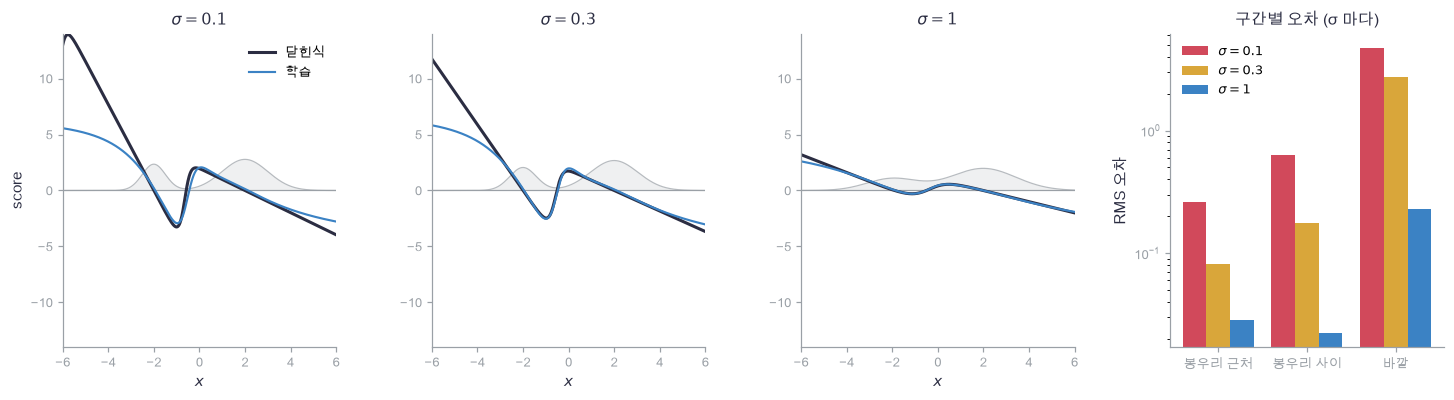

In [55]:
plot_sigma_comparison(score_x, compare_sigmas, compare_pdf, compare_true, compare_learned, list(score_regions), compare_regions)

🔍 **확인** · $\sigma=0.1$의 정답 score는 봉우리 사이에서 가파르고 학습 곡선이 거기서 크게 빗나갑니다. $\sigma=1.0$은 정답 자체가 완만하고 데이터가 어디에나 있어 곡선이 거의 겹치며 구간별 오차가 모두 작습니다. 그러나 $\sigma=1.0$의 $q_\sigma$는 원래 $p$와 다른 분포입니다. "정확하지만 다른 분포"와 "같은 분포지만 사이가 틀림" 사이의 절충이 33번의 잡음 사다리입니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 밀도 대신 score를 배우면 정규화 상수 $Z$가 왜 문제되지 않는지, 그리고 정답 score 없이 목적을 계산할 수 있는 이유(부분적분)를 말할 수 있나요? → 1·2절
- **수식:** 잡음 조건부 score $-\epsilon/\sigma$가 왜 정답 역할을 하고, DSM의 최소해가 $p$가 아니라 $q_\sigma$의 score인 이유를 쓸 수 있나요? 혼합의 $q_\sigma$ score 닫힌식과 Tweedie 항등을 쓸 수 있나요? → 3절
- **구현:** DSM 손실의 출력 기울기부터 MLP backward, Adam, 미니배치 루프까지 직접 쓰고 gradcheck를 통과시킬 수 있나요? → 4절
- **변형:** $\sigma$를 바꾸면 정답 score와 학습 오차가 어떻게 달라지는지, 오르막과 Langevin 걸음이 어떻게 다른지 설명할 수 있나요? → 4·5절

다음은 [33 NCSN](33_ncsn.ipynb)입니다. 이 노트북의 DSM 손실을 여러 $\sigma$에 걸쳐 하나의 모델로 학습하고, 큰 $\sigma$에서 작은 $\sigma$로 내려가는 annealed Langevin으로 혼합과 MNIST 좌표의 샘플을 만듭니다.

📎 [Hyvärinen 2005](https://jmlr.org/papers/v6/hyvarinen05a.html)가 2절의 정답 없는 목적(score matching), [Vincent 2011](https://www.iro.umontreal.ca/~vincentp/Publications/smdae_techreport.pdf)이 3절의 DSM과 잡음 낀 분포의 score, [Song·Ermon 2019](https://arxiv.org/abs/1907.05600)가 4·5절의 신경망 score 모델과 Langevin 샘플링을 잡음 수준 여러 개로 확장한 원논문입니다. 이 노트북의 혼합 예제와 모델은 설명을 위해 새로 구성한 것이며 원논문의 재현 실험은 아닙니다.